# Linnorm on the NCS: an auditable reservoir-to-host tie-in decision with OPM Flow and NeqSim master

**Open data → evidence register → E300 fluid analogue → five OPM Flow reservoir cases →
subsea flow assurance → multi-area host process capacity → holdback, economics, uncertainty,
and a gated recommendation.**

This long-form Colab uses the undeveloped **6406/9-1 Linnorm** gas discovery and compares the
two host candidates that Equinor has publicly named: **Kristin** and **Åsgard B**. It resolves and
records the current NeqSim `master` commit at run time. The saved outputs in this notebook were
produced with commit `ab314d6a0fceafe2f5f2a60213a70b7db3d7fccf`, which added multi-area
host tie-in capacity planning.

> This is a screening study, not a field development plan, reserves audit, history match, or
> capacity booking. Public facts, derived values, engineering analogues, scenarios, and decision
> rules are kept in separate columns throughout.

## Decision question and answer standard

**Question:** Can a staged Linnorm subsea development be produced without material holdback through
Kristin or Åsgard B, what modifications dominate, and which concept should enter concept select?

The notebook only recommends a concept when all five gates are visible:

1. reservoir deliverability and resource recovery;
2. wellhead-to-host hydraulic and flow-assurance feasibility;
3. host nameplate and equipment-level utilization;
4. holdback/deferment and value;
5. uncertainty and missing-data exposure.

The recommendation is therefore **conditional**. Proprietary PVT, pressure surveys, host operating
envelopes, metallurgy, layouts, shutdown logic, tariffs, and commercial terms can reverse it.

## Integrated calculation chain

```mermaid
flowchart TD
  A["SODIR open facts and geometry"] --> B["Evidence and assumption register"]
  B --> C["E300-based NeqSim fluids"]
  C --> D["Linnorm + host OPM Flow models"]
  D --> E["NeqSim wells and SURF"]
  E --> F["Multi-area host process model"]
  F --> G["Holdback and utilization"]
  G --> H["Economics and uncertainty"]
  H --> I["Gated tie-in recommendation"]
```

OPM Flow supplies pressure, gas-rate, cumulative-production, and restart states. NeqSim supplies
compositional thermodynamics, PVT, reconstructed well streams, pipeline hydraulics, hydrate and
corrosion screening, detailed separation/compression/amine calculations, and the new Java-master
multi-area capacity/holdback decision API.

## Evidence discipline

| Class | Meaning | May drive a recommendation? |
|---|---|---|
| `PUBLISHED` | Directly reported by SODIR, Equinor, Gassco, or OPM | Yes, with source date |
| `DERIVED` | Transparent calculation from published inputs | Yes, with formula |
| `ANALOGUE` | Engineering value used where open data is absent | Only through sensitivity |
| `SCENARIO` | Deliberately varied development or commercial choice | Yes, as a comparison |
| `DECISION` | Rule or gate imposed in this notebook | Yes, visibly |

No synthetic value is presented as a Linnorm measurement. The phrase “model calibration” below
means bulk pore volume is scaled to a public recoverable-resource target under an assumed recovery
factor; it does **not** mean a subsurface history match.

## 0. Runtime, NeqSim master, and OPM Flow

In [1]:
import importlib.util
import os
import subprocess
import sys

try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
package_map = {
    "bs4": "beautifulsoup4",
    "jpype": "jpype1",
    "lxml": "lxml",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "opm": "opm==2026.4",
    "pandas": "pandas",
    "requests": "requests",
}
missing = [package for module, package in package_map.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

print("Runtime:", "Google Colab" if IN_COLAB else "local validation")
print("Python:", sys.version.split()[0])
print("Installed/available:", ", ".join(package_map))

Runtime: local validation
Python: 3.12.13
Installed/available: bs4, jpype, lxml, matplotlib, numpy, opm, pandas, requests


In [2]:
import hashlib
import io
import json
import math
import re
import shutil
import statistics
import time
import urllib.parse
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")
RNG = np.random.default_rng(6406091)

def run_command(command, *, cwd=None, env=None, timeout=900, check=True):
    # Retain enough diagnostics for an auditable notebook.
    result = subprocess.run(
        command,
        cwd=cwd,
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        timeout=timeout,
    )
    if check and result.returncode != 0:
        tail = "\n".join(result.stdout.splitlines()[-80:])
        raise RuntimeError(f"Command failed ({result.returncode}): {command}\n{tail}")
    return result

SESSION_UTC = datetime.now(timezone.utc).isoformat(timespec="seconds")
print("Session UTC:", SESSION_UTC)

Session UTC: 2026-08-01T10:14:29+00:00


In [3]:
# Default: resolve the current NeqSim Java master. Set NEQSIM_MASTER_REF to a SHA for replay.
MASTER_REF = os.environ.get("NEQSIM_MASTER_REF", "master")
MASTER_SHA = os.environ.get("NEQSIM_MASTER_SHA", "").strip()
MASTER_CLASSPATH = os.environ.get("NEQSIM_MASTER_CLASSPATH", "").strip()

if not MASTER_SHA:
    commit_url = f"https://api.github.com/repos/equinor/neqsim/commits/{MASTER_REF}"
    response = requests.get(commit_url, timeout=60)
    response.raise_for_status()
    MASTER_SHA = response.json()["sha"]

if MASTER_CLASSPATH:
    # Local validation can supply a compiled classpath. Colab follows the full source-build path.
    master_classpath = MASTER_CLASSPATH.split(os.pathsep)
    master_source = Path(os.environ.get("NEQSIM_MASTER_SOURCE", "."))
else:
    if IN_COLAB:
        run_command(["apt-get", "update", "-qq"], timeout=300)
        run_command(
            ["apt-get", "install", "-y", "-qq", "openjdk-17-jdk-headless"],
            timeout=600,
        )
    build_root = Path("/content") if IN_COLAB else Path.cwd()
    archive = build_root / f"neqsim-{MASTER_SHA}.zip"
    source_parent = build_root / "neqsim-master-source"
    source_parent.mkdir(parents=True, exist_ok=True)
    if not archive.exists():
        archive_url = f"https://github.com/equinor/neqsim/archive/{MASTER_SHA}.zip"
        with requests.get(archive_url, stream=True, timeout=180) as download:
            download.raise_for_status()
            with archive.open("wb") as handle:
                for chunk in download.iter_content(1024 * 1024):
                    handle.write(chunk)
    master_source = source_parent / f"neqsim-{MASTER_SHA}"
    if not master_source.exists():
        with zipfile.ZipFile(archive) as zipped:
            zipped.extractall(source_parent)
    maven_env = os.environ.copy()
    maven_env["MAVEN_OPTS"] = "-Xmx3g"
    build = run_command(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=master_source,
        env=maven_env,
        timeout=1200,
    )
    jars = sorted((master_source / "target").glob("neqsim-*.jar"))
    jars = [path for path in jars if "sources" not in path.name and "javadoc" not in path.name]
    if not jars:
        raise FileNotFoundError("NeqSim master build produced no shaded jar")
    master_classpath = [str(jars[-1])]

if not jpype.isJVMStarted():
    jpype.startJVM(classpath=master_classpath)

J = jpype.JClass
HostFacility = J("neqsim.process.fielddevelopment.tieback.HostFacility")
code_source = HostFacility.class_.getProtectionDomain().getCodeSource().getLocation()
print("NeqSim master SHA:", MASTER_SHA)
print("Java code source:", code_source)

NeqSim master SHA: ab314d6a0fceafe2f5f2a60213a70b7db3d7fccf
Java code source: file:/tmp/neqsim-master-overlay2-04ade5/


In [4]:
# Fail early if a future master changes the tie-in API contract used by this notebook.
api_contract = {
    "neqsim.process.processmodel.ProcessModel": {
        "resolveStreamReference", "getCapacityUtilizationSummary", "findBottleneck",
        "isAnyHardLimitExceeded", "getUtilizationSnapshotJson", "setPropertyInitLevel",
        "validateAll", "checkMassBalance",
    },
    "neqsim.process.fielddevelopment.tieback.HostFacility": {
        "builder", "getProcessModel", "assessCapacity",
    },
    "neqsim.process.fielddevelopment.tieback.capacity.TieInCapacityPlanner": {
        "setHostProductionProfile", "setSatelliteProductionProfile", "setTieInPoint",
        "setAllocationPolicy", "setHoldbackPolicy", "run",
    },
}
contract_rows = []
for class_name, required_methods in api_contract.items():
    java_class = J(class_name)
    available = {str(method.getName()) for method in java_class.class_.getMethods()}
    missing_methods = sorted(required_methods - available)
    contract_rows.append({
        "class": class_name.rsplit(".", 1)[-1],
        "required_methods": len(required_methods),
        "missing": ", ".join(missing_methods) or "none",
    })
    assert not missing_methods, f"NeqSim master API changed: {class_name}: {missing_methods}"
api_contract_df = pd.DataFrame(contract_rows)
display(api_contract_df)

,class,required_methods,missing
0,ProcessModel,8,none
1,HostFacility,3,none
2,TieInCapacityPlanner,6,none


In [5]:
FLOW_BINARY = os.environ.get("FLOW_BINARY", "").strip() or shutil.which("flow")
if not FLOW_BINARY and IN_COLAB:
    run_command(["apt-get", "update", "-qq"], timeout=300)
    run_command(["apt-get", "install", "-y", "-qq", "software-properties-common"])
    run_command(["add-apt-repository", "-y", "ppa:opm/ppa"], timeout=300)
    run_command(["apt-get", "update", "-qq"], timeout=300)
    run_command(
        ["apt-get", "install", "-y", "-qq", "libopm-simulators-bin"],
        timeout=600,
    )
    FLOW_BINARY = shutil.which("flow")
if not FLOW_BINARY:
    raise RuntimeError("OPM Flow executable is unavailable")

FLOW_ENV = os.environ.copy()
opm_prefix = os.environ.get("OPM_PREFIX", "").strip()
if opm_prefix:
    FLOW_ENV["OPAL_PREFIX"] = f"{opm_prefix}/usr"
    local_libs = [f"{opm_prefix}/usr/lib/x86_64-linux-gnu",
                  f"{opm_prefix}/lib/x86_64-linux-gnu"]
    prior = FLOW_ENV.get("LD_LIBRARY_PATH", "")
    FLOW_ENV["LD_LIBRARY_PATH"] = ":".join(local_libs + ([prior] if prior else []))
    FLOW_ENV["PATH"] = f"{opm_prefix}/usr/bin:" + FLOW_ENV.get("PATH", "")
FLOW_ENV["OMP_NUM_THREADS"] = "2"
FLOW_ENV["OMPI_MCA_btl"] = "self,tcp"

flow_version_run = run_command([FLOW_BINARY, "--version"], env=FLOW_ENV, timeout=120)
flow_version = next(
    line.strip() for line in flow_version_run.stdout.splitlines()
    if line.strip().startswith("flow ")
)
print("OPM", flow_version)

OPM flow 2026.04


In [6]:
RUN_ROOT = Path("linnorm_tie_in_run") / MASTER_SHA[:10]
DECK_DIR = RUN_ROOT / "decks"
FLOW_OUT = RUN_ROOT / "flow_output"
EXPORT_DIR = RUN_ROOT / "decision_package"
for directory in (DECK_DIR, FLOW_OUT, EXPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
print("Run directory:", RUN_ROOT.resolve())

Run directory: /workspace/scratch/04ade5196498/linnorm_tie_in_run/ab314d6a0f


## 1. Open NCS evidence: SODIR FactMaps, FactPages, facilities, reserves, and production statistics

The user-facing map starts at the [SODIR ArcGIS home](https://sodir.maps.arcgis.com/home/index.html).
The calculations use SODIR's corresponding daily-synchronised public FactMaps REST service, because
it is machine-readable and preserves IDs, geometry, units, and update fields. FactPages HTML supplies
well-test narrative and annual production tables. SODIR notes that map positions can be uncertain by
roughly 0–300 m and must not be used for navigation.

In [7]:
sources = pd.DataFrame([
    {
        "source": "SODIR Facts landing page",
        "url": "https://www.sodir.no/en/facts/",
        "use": "authoritative entry point",
        "licence": "site terms / linked open datasets",
    },
    {
        "source": "SODIR open data",
        "url": "https://www.sodir.no/en/facts/data-and-analyses/open-data/",
        "use": "data access and caveats",
        "licence": "Norwegian Licence for Open Government Data 2.0",
    },
    {
        "source": "SODIR FactMaps WGS84 FeatureServer",
        "url": "https://factmaps.sodir.no/api/rest/services/Factmaps/FactMapsWGS84/FeatureServer",
        "use": "discovery, field, facility, pipeline and reserve features",
        "licence": "NLOD 2.0",
    },
    {
        "source": "SODIR well 6406/9-1",
        "url": "https://factpages.sodir.no/wellbore/pageview/exploration/all/4927",
        "use": "formations, DST rates, CO2/H2S, temperature, depth",
        "licence": "public government facts",
    },
    {
        "source": "Equinor Linnorm announcement",
        "url": "https://www.equinor.com/news/20231214-increasing-ownership-linnorm-discovery",
        "use": "named host candidates",
        "licence": "public operator statement",
    },
    {
        "source": "Equinor Kristin field page",
        "url": "https://www.equinor.com/energy/kristin",
        "use": "published host capacity and HPHT context",
        "licence": "public operator statement",
    },
    {
        "source": "Equinor Åsgard field page",
        "url": "https://www.equinor.com/energy/asgard",
        "use": "existing tie-ins and export context",
        "licence": "public operator statement",
    },
    {
        "source": "Gassco transport map",
        "url": "https://gassco.eu/en/transport-map/",
        "use": "Åsgard Transport route, diameter and endpoints",
        "licence": "public operator information",
    },
    {
        "source": "OPM SPE5 E300 PVT",
        "url": "https://github.com/OPM/opm-publications/blob/1aef1411ac4ad953cece5684a380b46fddfb9357/dynamic_blackoil/SPE5e300PVT",
        "use": "public E300 EOS component basis",
        "licence": "ODbL / DbCL as stated in file",
    },
])
sources["retrieved_utc"] = SESSION_UTC
display(sources)

,source,url,use,licence,retrieved_utc
0,SODIR Facts landing page,https://www.sodir.no/en/facts/,authoritative entry point,site terms / linked open datasets,2026-08-01T10:14:29+00:00
1,SODIR open data,https://www.sodir.no/en/facts/data-and-analyses/open-data/,data access and caveats,Norwegian Licence for Open Government Data 2.0,2026-08-01T10:14:29+00:00
2,SODIR FactMaps WGS84 FeatureServer,https://factmaps.sodir.no/api/rest/services/Factmaps/FactMapsWGS84/FeatureServer,"discovery, field, facility, pipeline and reserve features",NLOD 2.0,2026-08-01T10:14:29+00:00
3,SODIR well 6406/9-1,https://factpages.sodir.no/wellbore/pageview/exploration/all/4927,"formations, DST rates, CO2/H2S, temperature, depth",public government facts,2026-08-01T10:14:29+00:00
4,Equinor Linnorm announcement,https://www.equinor.com/news/20231214-increasing-ownership-linnorm-discovery,named host candidates,public operator statement,2026-08-01T10:14:29+00:00
5,Equinor Kristin field page,https://www.equinor.com/energy/kristin,published host capacity and HPHT context,public operator statement,2026-08-01T10:14:29+00:00
6,Equinor Åsgard field page,https://www.equinor.com/energy/asgard,existing tie-ins and export context,public operator statement,2026-08-01T10:14:29+00:00
7,Gassco transport map,https://gassco.eu/en/transport-map/,"Åsgard Transport route, diameter and endpoints",public operator information,2026-08-01T10:14:29+00:00
8,OPM SPE5 E300 PVT,https://github.com/OPM/opm-publications/blob/1aef1411ac4ad953cece5684a380b46fddfb9357/...,public E300 EOS component basis,ODbL / DbCL as stated in file,2026-08-01T10:14:29+00:00


In [8]:
ARCGIS = "https://factmaps.sodir.no/api/rest/services/Factmaps/FactMapsWGS84/FeatureServer"

def arcgis_query(layer, where="1=1", *, geometry=None, out_fields="*", return_geometry=True):
    params = {
        "f": "json",
        "where": where,
        "outFields": out_fields,
        "returnGeometry": str(return_geometry).lower(),
        "outSR": 4326,
    }
    if geometry is not None:
        params.update({
            "geometry": geometry,
            "geometryType": "esriGeometryEnvelope",
            "spatialRel": "esriSpatialRelIntersects",
        })
    response = requests.get(f"{ARCGIS}/{layer}/query", params=params, timeout=90)
    response.raise_for_status()
    payload = response.json()
    if "error" in payload:
        raise RuntimeError(payload["error"])
    return payload.get("features", [])

layer_ids = {
    "wells_all": 201,
    "facilities_in_place": 304,
    "pipelines": 311,
    "fields": 502,
    "discoveries_all": 504,
    "field_reserves": 515,
    "discovery_resources": 532,
}
service = requests.get(ARCGIS, params={"f": "json"}, timeout=90).json()
layer_registry = pd.DataFrame(service["layers"])
layer_registry = layer_registry[layer_registry["id"].isin(layer_ids.values())]
display(layer_registry[["id", "name"]].sort_values("id"))

,id,name
0,201,"Wellbores, all"
6,304,"Facilities, in place"
9,311,Pipelines
33,502,Field by status
35,504,"Discovery, all - by main HC type"


In [9]:
# Stable NPD/SODIR IDs prevent name and language drift.
linnorm_features = arcgis_query(504, "dscNpdidDiscovery=3435686")
linnorm_resources = arcgis_query(532, "dscNpdidDiscovery=3435686", return_geometry=False)
host_fields = arcgis_query(502, "fldNpdidField IN (1854729,43765)")
host_reserves = arcgis_query(515, "fldNpdidField IN (1854729,43765)", return_geometry=False)
host_facilities = arcgis_query(
    304,
    "fclName IN ('KRISTIN','ÅSGARD B','KRISTIN T','ÅSGARD T','ÅSGARD ERB')",
)
export_pipelines = arcgis_query(
    311,
    "UPPER(pplName) LIKE '%ÅSGARD%' OR UPPER(pplName) LIKE '%KRISTIN%'",
)
nearby_discoveries = arcgis_query(504, geometry="6.1,64.2,7.4,65.35")

assert len(linnorm_features) == 1
assert len(linnorm_resources) == 1
assert {f["attributes"]["fldName"] for f in host_fields} == {"KRISTIN", "ÅSGARD"}
print({
    "Linnorm polygons": len(linnorm_features),
    "host fields": len(host_fields),
    "host/export facilities": len(host_facilities),
    "named export pipelines": len(export_pipelines),
    "nearby discoveries": len(nearby_discoveries),
})

{'Linnorm polygons': 1, 'host fields': 2, 'host/export facilities': 5, 'named export pipelines': 2, 'nearby discoveries': 49}


In [10]:
discovery = linnorm_features[0]["attributes"]
resources = linnorm_resources[0]["attributes"]
field_reserve_by_id = {
    row["attributes"]["fldNpdidField"]: row["attributes"] for row in host_reserves
}
facility_by_name = {
    row["attributes"]["fclName"]: row for row in host_facilities
}

evidence = pd.DataFrame([
    ["Linnorm status", discovery["dscCurrentActivityStatus"], "PUBLISHED", "SODIR discovery 3435686"],
    ["hydrocarbon type", discovery["dscHcType"], "PUBLISHED", "SODIR discovery 3435686"],
    ["recoverable gas", resources["dscRecoverableGas"], "PUBLISHED", "BSm3; SODIR resource estimate"],
    ["recoverable oil", resources["dscRecoverableOil"], "PUBLISHED", "MSm3; SODIR resource estimate"],
    ["resource class", resources["dscReservesRC"], "PUBLISHED", "SODIR resource classification"],
    ["resource estimate date", pd.to_datetime(resources["dscDateOffResEstDisplay"], unit="ms").date(),
     "PUBLISHED", "SODIR"],
    ["Kristin remaining gas", field_reserve_by_id[1854729]["fldRemainingGas"], "PUBLISHED", "BSm3; SODIR"],
    ["Åsgard remaining gas", field_reserve_by_id[43765]["fldRemainingGas"], "PUBLISHED", "BSm3; SODIR"],
    ["Kristin rich-gas capacity", 18.0, "PUBLISHED", "MSm3/d; Equinor says just over 18"],
    ["Åsgard Transport capacity", 72.0, "PUBLISHED", "MSm3/d; Gassco Kårstø brochure"],
], columns=["item", "value", "class", "source_or_unit"])
display(evidence)

,item,value,class,source_or_unit
0,Linnorm status,Production likely but unclarified,PUBLISHED,SODIR discovery 3435686
1,hydrocarbon type,GAS,PUBLISHED,SODIR discovery 3435686
2,recoverable gas,31.41,PUBLISHED,BSm3; SODIR resource estimate
3,recoverable oil,0.703,PUBLISHED,MSm3; SODIR resource estimate
4,resource class,5F,PUBLISHED,SODIR resource classification
5,resource estimate date,2025-12-30,PUBLISHED,SODIR
6,Kristin remaining gas,8.076,PUBLISHED,BSm3; SODIR
7,Åsgard remaining gas,21.23,PUBLISHED,BSm3; SODIR
8,Kristin rich-gas capacity,18,PUBLISHED,MSm3/d; Equinor says just over 18
9,Åsgard Transport capacity,72,PUBLISHED,MSm3/d; Gassco Kårstø brochure


In [11]:
WELL_URL = "https://factpages.sodir.no/wellbore/pageview/exploration/all/4927"
well_html = requests.get(WELL_URL, timeout=90).text
well_text = " ".join(BeautifulSoup(well_html, "html.parser").stripped_strings)

published_well_facts = {
    "bottom_hole_temperature_C": 184.0,
    "total_depth_m_RKB": 5080.0,
    "water_depth_m": 308.0,
    "hydrocarbon_column_m": 492.5,
    "co2_mol_pct_low": 7.0,
    "co2_mol_pct_high": 8.0,
    "h2s_ppm_low": 15.0,
    "h2s_ppm_high": 30.0,
    "dst_tilje_MSm3d": 1.410,
    "dst_ile_MSm3d": 0.770,
    "reported_compartments_up_to": 5,
}
verification_patterns = {
    "CO2 7-8%": r"CO2 content was 7-8%",
    "Tilje DST 1.41 MSm3/d": r"1410000 Sm3/day",
    "Ile DST 0.77 MSm3/d": r"770000 Sm3/day",
    "492.5 m column": r"492\.5 m",
    "five compartments": r"up to 5 different compartments",
}
page_checks = pd.DataFrame([
    {"check": label, "found_on_live_page": bool(re.search(pattern, well_text, re.I))}
    for label, pattern in verification_patterns.items()
])
assert page_checks["found_on_live_page"].all()
display(page_checks)
display(pd.DataFrame([published_well_facts]).T.rename(columns={0: "published value"}))

,check,found_on_live_page
0,CO2 7-8%,True
1,Tilje DST 1.41 MSm3/d,True
2,Ile DST 0.77 MSm3/d,True
3,492.5 m column,True
4,five compartments,True


,published value
bottom_hole_temperature_C,184
total_depth_m_RKB,"5,080"
water_depth_m,308
hydrocarbon_column_m,492.5
co2_mol_pct_low,7
co2_mol_pct_high,8
h2s_ppm_low,15
h2s_ppm_high,30
dst_tilje_MSm3d,1.41
dst_ile_MSm3d,0.77


In [12]:
production_fallback = {
    "KRISTIN": {
        2019: 0.800605, 2020: 0.682837, 2021: 0.566721, 2022: 0.502487,
        2023: 0.405132, 2024: 0.469256, 2025: 1.037103,
    },
    "ÅSGARD": {
        2019: 8.837206, 2020: 6.673387, 2021: 5.391018, 2022: 5.513845,
        2023: 4.920069, 2024: 4.041596, 2025: 4.586188,
    },
}

def read_field_production(field_name, field_id):
    url = f"https://factpages.sodir.no/field/pageview/all/{field_id}"
    try:
        html = requests.get(url, timeout=90).text
        tables = pd.read_html(io.StringIO(html))
        table = next(
            item for item in tables
            if any("Net – gas" in str(column) for column in item.columns)
        ).copy()
        year_column = table.columns[0]
        gas_column = next(column for column in table.columns if "Net – gas" in str(column))
        table["year"] = pd.to_numeric(table[year_column], errors="coerce")
        table["gas_BSm3"] = pd.to_numeric(table[gas_column], errors="coerce")
        result = table.dropna(subset=["year", "gas_BSm3"])[["year", "gas_BSm3"]]
        result["year"] = result["year"].astype(int)
        result["source_mode"] = "live FactPages table"
        return result
    except Exception as error:
        result = pd.DataFrame({
            "year": list(production_fallback[field_name]),
            "gas_BSm3": list(production_fallback[field_name].values()),
        })
        result["source_mode"] = f"embedded snapshot ({type(error).__name__})"
        return result

production = pd.concat([
    read_field_production("KRISTIN", 1854729).assign(field="KRISTIN"),
    read_field_production("ÅSGARD", 43765).assign(field="ÅSGARD"),
], ignore_index=True)
production = production[(production["year"] >= 2010) & (production["year"] <= 2025)].copy()
production["average_MSm3d"] = production["gas_BSm3"] * 1000.0 / 365.25
display(production.sort_values(["field", "year"]).tail(12))

,year,gas_BSm3,source_mode,field,average_MSm3d
34,2014,9.899,live FactPages table,ÅSGARD,27.1
33,2015,9.806,live FactPages table,ÅSGARD,26.85
32,2016,10.24,live FactPages table,ÅSGARD,28.03
31,2017,10.2,live FactPages table,ÅSGARD,27.93
30,2018,9.699,live FactPages table,ÅSGARD,26.55
29,2019,8.837,live FactPages table,ÅSGARD,24.19
28,2020,6.673,live FactPages table,ÅSGARD,18.27
27,2021,5.391,live FactPages table,ÅSGARD,14.76
26,2022,5.514,live FactPages table,ÅSGARD,15.1
25,2023,4.92,live FactPages table,ÅSGARD,13.47


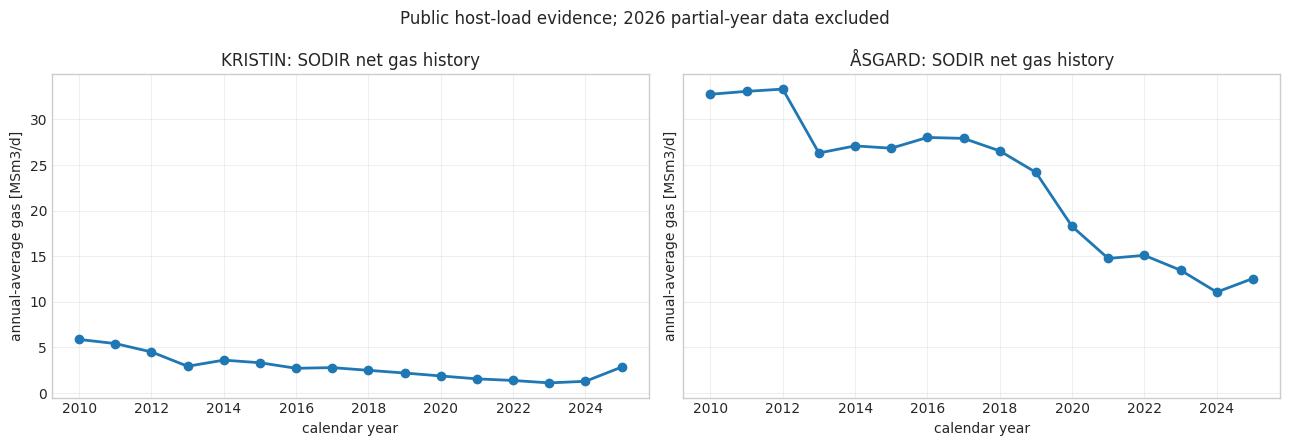

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for axis, field_name in zip(axes, ["KRISTIN", "ÅSGARD"]):
    subset = production[production["field"] == field_name].sort_values("year")
    axis.plot(subset["year"], subset["average_MSm3d"], marker="o", lw=2)
    axis.set_title(f"{field_name}: SODIR net gas history")
    axis.set_xlabel("calendar year")
    axis.set_ylabel("annual-average gas [MSm3/d]")
    axis.grid(alpha=0.3)
fig.suptitle("Public host-load evidence; 2026 partial-year data excluded")
fig.tight_layout()
plt.show()

In [14]:
def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    phi1, phi2 = np.radians([lat1, lat2])
    dphi = phi2 - phi1
    dlambda = np.radians(lon2 - lon1)
    term = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return float(2 * radius_km * np.arctan2(np.sqrt(term), np.sqrt(1 - term)))

linnorm_well = {"lat": 64 + 26/60 + 46.85/3600, "lon": 6 + 48/60 + 55.23/3600}
host_rows = []
for host_name in ("KRISTIN", "ÅSGARD B"):
    feature = facility_by_name[host_name]
    geometry = feature["geometry"]
    attrs = feature["attributes"]
    host_rows.append({
        "host": host_name,
        "latitude": geometry["y"],
        "longitude": geometry["x"],
        "water_depth_m": attrs["fclWaterDepth"],
        "functions": attrs["fclFunctions"],
        "straight_line_km": haversine_km(
            linnorm_well["lat"], linnorm_well["lon"], geometry["y"], geometry["x"]
        ),
        "class": "DERIVED from SODIR coordinates",
    })
host_candidates = pd.DataFrame(host_rows)
display(host_candidates)

,host,latitude,longitude,water_depth_m,functions,straight_line_km,class
0,KRISTIN,64.99,6.55,360,GAS PRODUCER - OIL PRODUCER - PROCESSING - QUARTER,62.15,DERIVED from SODIR coordinates
1,ÅSGARD B,65.11,6.789,300,GAS EXPORT - PROCESSING - QUARTER,73.82,DERIVED from SODIR coordinates


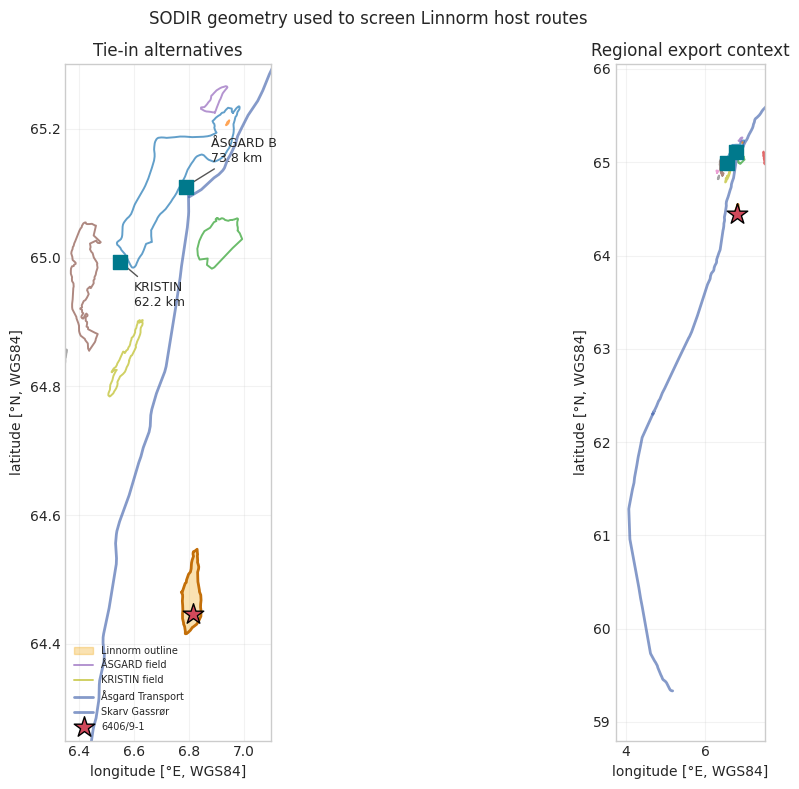

In [15]:
def plot_sodir_context(axis, view):
    for ring in linnorm_features[0].get("geometry", {}).get("rings", []):
        points = np.asarray(ring)
        axis.fill(
            points[:, 0], points[:, 1], color="#f0a202", alpha=0.30,
            label="Linnorm outline"
        )
        axis.plot(points[:, 0], points[:, 1], color="#c36f09", lw=2)

    for feature in host_fields:
        name = feature["attributes"]["fldName"]
        for ring in feature.get("geometry", {}).get("rings", []):
            points = np.asarray(ring)
            axis.plot(
                points[:, 0], points[:, 1], lw=1.4, alpha=0.7,
                label=f"{name} field"
            )

    for feature in export_pipelines:
        label = (
            feature["attributes"].get("pplMapLabel")
            or feature["attributes"].get("pplName")
        )
        for path in feature.get("geometry", {}).get("paths", []):
            points = np.asarray(path)
            axis.plot(
                points[:, 0], points[:, 1], color="#4464ad", lw=2,
                alpha=0.65, label=label
            )

    axis.scatter(
        linnorm_well["lon"], linnorm_well["lat"], marker="*", s=240,
        color="#d1495b", edgecolor="black", zorder=5, label="6406/9-1"
    )
    label_offsets = {"KRISTIN": (10, -32), "ÅSGARD B": (18, 18)}
    for row in host_candidates.itertuples():
        axis.scatter(
            row.longitude, row.latitude, marker="s", s=100,
            color="#00798c", zorder=5
        )
        if view == "local":
            x_offset, y_offset = label_offsets[row.host]
            axis.annotate(
                f"{row.host}\n{row.straight_line_km:.1f} km",
                (row.longitude, row.latitude), xytext=(x_offset, y_offset),
                textcoords="offset points", fontsize=9,
                arrowprops={"arrowstyle": "-", "color": "#555555"},
            )

    axis.set_xlabel("longitude [°E, WGS84]")
    axis.set_ylabel("latitude [°N, WGS84]")
    axis.set_aspect(1 / np.cos(np.radians(64.8)))
    axis.grid(alpha=0.25)
    if view == "local":
        axis.set_xlim(6.35, 7.10)
        axis.set_ylim(64.25, 65.30)
        axis.set_title("Tie-in alternatives")
    else:
        axis.set_xlim(3.75, 7.50)
        axis.set_ylim(58.80, 66.05)
        axis.set_title("Regional export context")

fig, axes = plt.subplots(1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [1.25, 0.9]})
plot_sodir_context(axes[0], "local")
plot_sodir_context(axes[1], "regional")
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
axes[0].legend(unique.values(), unique.keys(), loc="lower left", fontsize=7)
fig.suptitle("SODIR geometry used to screen Linnorm host routes")
fig.tight_layout()
plt.show()

### What the open data does—and does not—establish

SODIR establishes the discovery outline, well position, formations, DST evidence, resource estimate,
status, field/facility identity, geometry, public host production, and the 42-inch Åsgard Transport
route. Equinor establishes that Kristin and Åsgard B are under evaluation. None of these sources
publishes current host equipment margins, a Linnorm EOS model, relative permeability, fault
transmissibility, tubing/VFP, flowline route survey, CO2-treatment margin, or commercial access.

Straight-line distance is therefore only a routing lower bound. The model uses route factors and
cost sensitivities; it never treats the map as a construction survey.

## 2. From a public E300 fluid basis to three transparent NeqSim analogues

The following public file is the `SPE5e300PVT` dataset in OPM Publications. Its PR-EOS component
slate is used as the heavy-end basis requested for this exercise. Linnorm molar fractions are not
copied from SPE5: the public well evidence says the gas is unusually dry, with 7–8 mol% CO2 and
15–30 ppm H2S. We therefore preserve the E300 critical-property/component structure while retuning
the mixture and adding N2, C2 and trace H2S using NeqSim's database.

In [16]:
SPE5_E300_TEXT = """
NCOMPS
7 /
EOS
PR /
PRCORR
STCOND
59.0 14.695948775 /
RTEMP
159.9980 /
CNAMES
CO2 C1 C3 N-C6 N-C10 N-C15 N-C20 /
MW
44.0094 16.0425 44.0956 86.1753 142.2815 212.4142 282.5469 /
TCRIT
547.4412 343.0152 665.802 914.022 1111.914 1274.22 1381.5 /
PCRIT
1070.1319402933 667.0575633678 616.5844306378 439.8994585351
305.4494756594 214.5108141027 155.1903793711 /
ACF
0.22492 0.011406 0.1521 0.2986 0.4896 0.6955 0.8913 /
OMEGAA
0.457236 0.457236 0.457236 0.457236 0.457236 0.457236 0.457236 /
OMEGAB
0.0777961 0.0777961 0.0777961 0.0777961 0.0777961 0.0777961 0.0777961 /
ZCRIT
0.275 0.286 0.28 0.26 0.26 0.24 0.22 /
BIC
0.1209
0.1310 0.0339
0.1141 0.0321 0.0094
0.1027 0.0407 0.0145 -0.0009
0.0871 0.0442 0.0110 -0.0068 -0.0023
0.0646 0.0408 -0.0021 -0.0202 -0.0110 -0.0031 /
ZMFVD
1.0 0.0 0.50 0.03 0.07 0.20 0.15 0.05
8425.0 0.0 0.50 0.03 0.07 0.20 0.15 0.05 /
"""
E300_SOURCE_SHA = "401b76acb9e52d0c9722186a212c2578090c4175"
print("Embedded OPM E300 blob SHA:", E300_SOURCE_SHA)
print("Text SHA256:", hashlib.sha256(SPE5_E300_TEXT.encode()).hexdigest())

Embedded OPM E300 blob SHA: 401b76acb9e52d0c9722186a212c2578090c4175
Text SHA256: b6d998f0fa41b74c6542dd3914b4f24fb6d5af40dc30134e28361111481bfaed


In [17]:
def parse_e300_block(text, keyword):
    match = re.search(rf"(?:^|\n)\s*{re.escape(keyword)}\s+(.*?)/", text, flags=re.I | re.S)
    if not match:
        raise KeyError(keyword)
    return match.group(1).split()

component_names = parse_e300_block(SPE5_E300_TEXT, "CNAMES")
e300 = pd.DataFrame({
    "E300 name": component_names,
    "NeqSim name": ["CO2", "methane", "propane", "n-hexane", "nC10", "nC15", "nC20"],
    "MW [g/mol]": np.asarray(parse_e300_block(SPE5_E300_TEXT, "MW"), float),
    "Tcrit [K]": np.asarray(parse_e300_block(SPE5_E300_TEXT, "TCRIT"), float) / 1.8,
    "Pcrit [bar]": np.asarray(parse_e300_block(SPE5_E300_TEXT, "PCRIT"), float) * 0.0689475729,
    "acentric factor": np.asarray(parse_e300_block(SPE5_E300_TEXT, "ACF"), float),
})
assert len(e300) == int(parse_e300_block(SPE5_E300_TEXT, "NCOMPS")[0])
display(e300)

,E300 name,NeqSim name,MW [g/mol],Tcrit [K],Pcrit [bar],acentric factor
0,CO2,CO2,44.01,304.1,73.78,0.2249
1,C1,methane,16.04,190.6,45.99,0.01141
2,C3,propane,44.1,369.9,42.51,0.1521
3,N-C6,n-hexane,86.18,507.8,30.33,0.2986
4,N-C10,nC10,142.3,617.7,21.06,0.4896
5,N-C15,nC15,212.4,707.9,14.79,0.6955
6,N-C20,nC20,282.5,767.5,10.7,0.8913


In [18]:
fluid_compositions = {
    "LINNORM": {
        "nitrogen": 0.0050,
        "CO2": 0.0750,
        "H2S": 0.000020,
        "methane": 0.8950,
        "ethane": 0.0150,
        "propane": 0.0050,
        "n-hexane": 0.0030,
        "nC10": 0.0015,
        "nC15": 0.0004,
        "nC20": 0.00008,
    },
    "KRISTIN": {
        "nitrogen": 0.005,
        "CO2": 0.010,
        "methane": 0.790,
        "ethane": 0.080,
        "propane": 0.050,
        "n-hexane": 0.035,
        "nC10": 0.020,
        "nC15": 0.007,
        "nC20": 0.003,
    },
    "ASGARD": {
        "nitrogen": 0.005,
        "CO2": 0.025,
        "methane": 0.820,
        "ethane": 0.070,
        "propane": 0.035,
        "n-hexane": 0.025,
        "nC10": 0.012,
        "nC15": 0.005,
        "nC20": 0.003,
    },
}
for composition in fluid_compositions.values():
    composition["methane"] += 1.0 - sum(composition.values())
    assert abs(sum(composition.values()) - 1.0) < 1e-12

composition_df = pd.DataFrame(fluid_compositions).fillna(0.0) * 100.0
composition_df.index.name = "component"
display(composition_df.rename(columns=lambda value: f"{value} [mol%]"))

,LINNORM [mol%],KRISTIN [mol%],ASGARD [mol%]
component,,,
nitrogen,0.5,0.5,0.5
CO2,7.5,1,2.5
H2S,0.002,0,0
methane,89.5,79,82
ethane,1.5,8,7
propane,0.5,5,3.5
n-hexane,0.3,3.5,2.5
nC10,0.15,2,1.2
nC15,0.04,0.7,0.5


In [19]:
SystemPrEos = J("neqsim.thermo.system.SystemPrEos")
SystemSrkCPAstatoil = J("neqsim.thermo.system.SystemSrkCPAstatoil")
ThermodynamicOperations = J("neqsim.thermodynamicoperations.ThermodynamicOperations")
Stream = J("neqsim.process.equipment.stream.Stream")

fluid_conditions = {
    "LINNORM": {"temperature_C": 184.0, "pressure_bara": 850.0, "pressure_class": "ANALOGUE"},
    "KRISTIN": {"temperature_C": 180.0, "pressure_bara": 300.0, "pressure_class": "ANALOGUE current"},
    "ASGARD": {"temperature_C": 150.0, "pressure_bara": 240.0, "pressure_class": "ANALOGUE current"},
}

def build_fluid(fluid_name, temperature_C=None, pressure_bara=None, eos_class=SystemPrEos):
    conditions = fluid_conditions[fluid_name]
    temperature_C = conditions["temperature_C"] if temperature_C is None else temperature_C
    pressure_bara = conditions["pressure_bara"] if pressure_bara is None else pressure_bara
    fluid = eos_class(float(temperature_C) + 273.15, float(pressure_bara))
    for component, fraction in fluid_compositions[fluid_name].items():
        if fraction > 0.0:
            fluid.addComponent(component, float(fraction))
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid

flash_rows = []
standard_density = {}
for fluid_name in fluid_compositions:
    fluid = build_fluid(fluid_name)
    ThermodynamicOperations(fluid).TPflash()
    fluid.initProperties()
    gas = fluid.getPhase("gas")
    standard = build_fluid(fluid_name, 15.0, 1.01325)
    ThermodynamicOperations(standard).TPflash()
    standard.initProperties()
    standard_density[fluid_name] = float(standard.getDensity("kg/m3"))
    flash_rows.append({
        "fluid": fluid_name,
        "T [C]": fluid_conditions[fluid_name]["temperature_C"],
        "P [bara]": fluid_conditions[fluid_name]["pressure_bara"],
        "phases": int(fluid.getNumberOfPhases()),
        "Z gas": float(gas.getZ()),
        "gas density [kg/m3]": float(gas.getDensity("kg/m3")),
        "gas viscosity [cP]": float(gas.getViscosity("cP")),
        "standard density [kg/Sm3]": standard_density[fluid_name],
    })
flash_summary = pd.DataFrame(flash_rows)
display(flash_summary)

,fluid,T [C],P [bara],phases,Z gas,gas density [kg/m3],gas viscosity [cP],standard density [kg/Sm3]
0,LINNORM,184,850,1,1.384,285.5,0.03706,0.809
1,KRISTIN,180,300,1,0.9868,203.9,0.02693,1.15
2,ASGARD,150,240,2,0.9307,167.8,0.02303,1.035


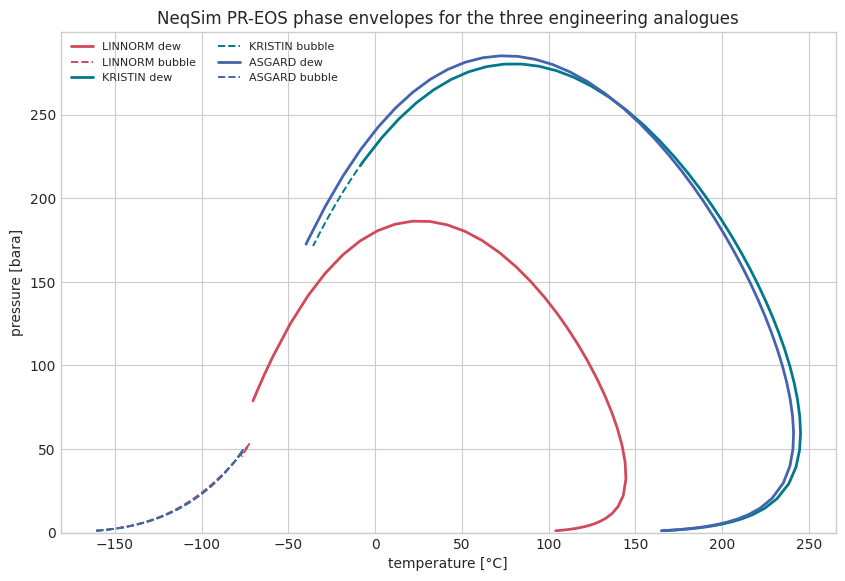

In [20]:
envelope_data = {}
for fluid_name in fluid_compositions:
    envelope_fluid = build_fluid(fluid_name, 20.0, 50.0)
    operations = ThermodynamicOperations(envelope_fluid)
    operations.calcPTphaseEnvelope()
    envelope_data[fluid_name] = {
        "dew_T_C": np.asarray(list(operations.get("dewT"))) - 273.15,
        "dew_P_bara": np.asarray(list(operations.get("dewP"))),
        "bubble_T_C": np.asarray(list(operations.get("bubT"))) - 273.15,
        "bubble_P_bara": np.asarray(list(operations.get("bubP"))),
        "cricondentherm": list(operations.get("cricondentherm")),
        "closed": bool(operations.getOperation().isEnvelopeClosed()),
    }

fig, ax = plt.subplots(figsize=(10, 6.5))
colors = {"LINNORM": "#d1495b", "KRISTIN": "#00798c", "ASGARD": "#4464ad"}
for fluid_name, data in envelope_data.items():
    ax.plot(data["dew_T_C"], data["dew_P_bara"], color=colors[fluid_name],
            lw=2, label=f"{fluid_name} dew")
    ax.plot(data["bubble_T_C"], data["bubble_P_bara"], color=colors[fluid_name],
            lw=1.4, ls="--", label=f"{fluid_name} bubble")
ax.set_xlabel("temperature [°C]")
ax.set_ylabel("pressure [bara]")
ax.set_title("NeqSim PR-EOS phase envelopes for the three engineering analogues")
ax.legend(ncol=2, fontsize=8)
ax.set_ylim(bottom=0)
plt.show()
assert all(item["closed"] for item in envelope_data.values())

The Linnorm reservoir point lies far above the hydrocarbon dew envelope in this analogue, consistent
with SODIR's “significantly drier than expected” observation. The rich host streams are intentionally
different: they are not substitutes for allocation metering or proprietary EOS models, but they stop
the process screen from treating every host molecule as dry methane.

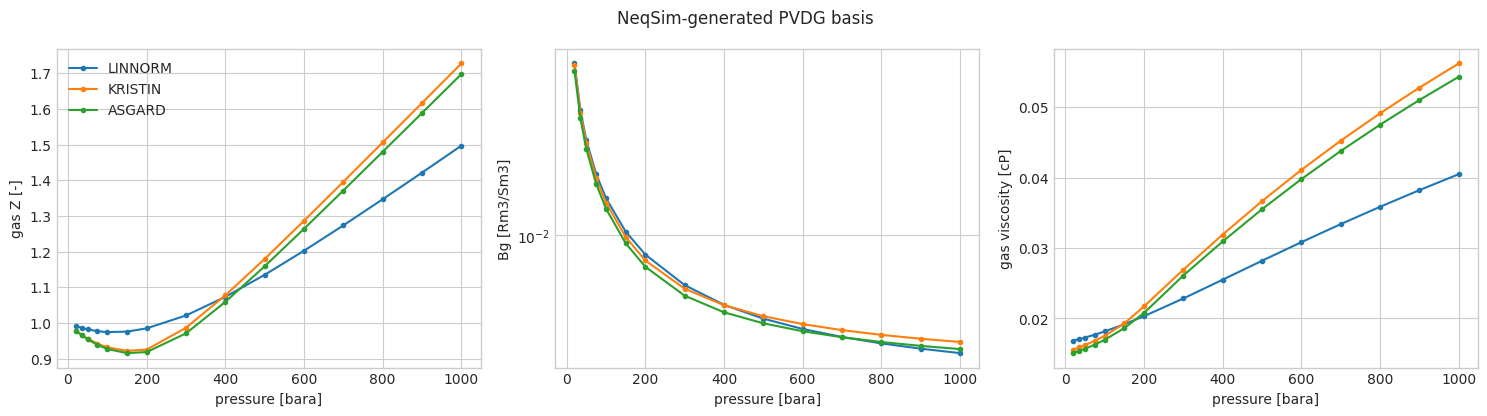

In [21]:
P_STD_BARA = 1.01325
T_STD_K = 288.15
pressure_grid = np.array([20, 35, 50, 75, 100, 150, 200, 300, 400, 500,
                          600, 700, 800, 900, 1000], dtype=float)

def generate_gas_pvt(fluid_name):
    temperature_K = fluid_conditions[fluid_name]["temperature_C"] + 273.15
    rows = []
    for pressure in pressure_grid:
        fluid = build_fluid(fluid_name, temperature_K - 273.15, pressure)
        ThermodynamicOperations(fluid).TPflash()
        fluid.initProperties()
        phase = fluid.getPhase("gas") if fluid.hasPhaseType("gas") else fluid.getPhase(0)
        z_factor = float(phase.getZ())
        bg = z_factor * temperature_K / T_STD_K * P_STD_BARA / pressure
        rows.append({
            "fluid": fluid_name,
            "pressure_bara": pressure,
            "z": z_factor,
            "Bg_Rm3_per_Sm3": bg,
            "gas_viscosity_cP": float(phase.getViscosity("cP")),
            "gas_density_kgm3": float(phase.getDensity("kg/m3")),
        })
    return pd.DataFrame(rows)

pvt_tables = {name: generate_gas_pvt(name) for name in fluid_compositions}
pvt_all = pd.concat(pvt_tables.values(), ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for fluid_name, table in pvt_tables.items():
    axes[0].plot(table["pressure_bara"], table["z"], marker="o", ms=3, label=fluid_name)
    axes[1].semilogy(table["pressure_bara"], table["Bg_Rm3_per_Sm3"], marker="o", ms=3)
    axes[2].plot(table["pressure_bara"], table["gas_viscosity_cP"], marker="o", ms=3)
axes[0].set_ylabel("gas Z [-]")
axes[1].set_ylabel("Bg [Rm3/Sm3]")
axes[2].set_ylabel("gas viscosity [cP]")
for axis in axes:
    axis.set_xlabel("pressure [bara]")
axes[0].legend()
fig.suptitle("NeqSim-generated PVDG basis")
fig.tight_layout()
plt.show()

For each pressure point, the Flow gas formation-volume factor is calculated from the NeqSim gas
compressibility factor:

$$B_g=Z\frac{T}{T_{sc}}\frac{p_{sc}}{p}$$

OPM Flow receives `PVDG` pressure, $B_g$, and NeqSim gas viscosity. This is a dry-gas black-oil
reduction of the compositional model. It retains pressure-dependent gas storage and mobility but
does not model compositional depletion, condensate banking, aqueous CO2, or H2S partitioning in the
reservoir. Those omissions are explicit model-form uncertainty.

## 4. Five auditable OPM Flow reservoir cases

The Flow models are deliberately compact enough for Colab while retaining the decision physics:
pressure depletion, non-uniform porosity and permeability, vertical layering, a sealing-fault
multiplier, aquifer-free gas expansion, well BHP constraints, and scheduled rate changes. Linnorm
low/base/high bracket public recoverable gas; the Kristin and Åsgard cases reconstruct declining
host supply rather than claiming access to proprietary host simulation models.

| Input family | Linnorm status | Host status |
|---|---|---|
| Recoverable gas | SODIR published (base), ± scenario range | SODIR remaining reserves |
| Initial pressure, porosity, permeability, NTG | analogue/scenario | analogue |
| Temperature | discovery well published for Linnorm | Kristin published; Åsgard analogue |
| Well count and targets | development scenario | calibrated to 2025 public field rate |
| Relperm and aquifer | analogue; no aquifer | analogue; no aquifer |

The purpose is to connect reservoir uncertainty to facility decisions—not to imitate a sanctioned
reservoir model. Base/high start with two wells, add the remaining well(s) in 2031, and close in
2043 at the scenario resource ceiling; the low case remains deliverability-limited. This makes
resource-limited abandonment visible in the schedule instead of producing beyond SODIR volumes.

In [22]:
CASES = {
    "LINNORM_LOW": {
        "fluid": "LINNORM", "nx": 18, "ny": 18, "nz": 6,
        "dx_m": 180.0, "dy_m": 180.0, "dz_m": 20.0, "top_m": 4500.0,
        "pressure_bara": 780.0, "temperature_C": 184.0,
        "porosity": 0.135, "ntg": 0.55, "perm_md": 12.0,
        "well_count": 2, "target_msm3d": 5.5, "bhp_bara": 130.0,
        "resource_bsm3": 26.0, "recovery_factor": 0.72,
    },
    "LINNORM_BASE": {
        "fluid": "LINNORM", "nx": 18, "ny": 18, "nz": 6,
        "dx_m": 180.0, "dy_m": 180.0, "dz_m": 20.0, "top_m": 4500.0,
        "pressure_bara": 850.0, "temperature_C": 184.0,
        "porosity": 0.15, "ntg": 0.70, "perm_md": 50.0,
        "well_count": 3, "target_msm3d": 6.3, "bhp_bara": 130.0,
        "resource_bsm3": 31.411, "recovery_factor": 0.75,
    },
    "LINNORM_HIGH": {
        "fluid": "LINNORM", "nx": 18, "ny": 18, "nz": 6,
        "dx_m": 180.0, "dy_m": 180.0, "dz_m": 20.0, "top_m": 4500.0,
        "pressure_bara": 900.0, "temperature_C": 184.0,
        "porosity": 0.17, "ntg": 0.78, "perm_md": 180.0,
        "well_count": 4, "target_msm3d": 7.8, "bhp_bara": 120.0,
        "resource_bsm3": 37.0, "recovery_factor": 0.78,
    },
    "KRISTIN_HOST": {
        "fluid": "KRISTIN", "nx": 8, "ny": 8, "nz": 3,
        "dx_m": 350.0, "dy_m": 350.0, "dz_m": 20.0, "top_m": 4500.0,
        "pressure_bara": 300.0, "temperature_C": 180.0,
        "porosity": 0.17, "ntg": 0.70, "perm_md": 35.0,
        "well_count": 2, "target_msm3d": 2.84, "bhp_bara": 90.0,
        "resource_bsm3": 8.076, "recovery_factor": 0.70,
    },
    "ASGARD_HOST": {
        "fluid": "ASGARD", "nx": 10, "ny": 10, "nz": 3,
        "dx_m": 450.0, "dy_m": 450.0, "dz_m": 18.0, "top_m": 3500.0,
        "pressure_bara": 240.0, "temperature_C": 150.0,
        "porosity": 0.16, "ntg": 0.70, "perm_md": 90.0,
        "well_count": 4, "target_msm3d": 12.1, "bhp_bara": 70.0,
        "resource_bsm3": 21.228, "recovery_factor": 0.70,
    },
}

case_table = pd.DataFrame(CASES).T[
    ["pressure_bara", "temperature_C", "porosity", "ntg", "perm_md",
     "well_count", "target_msm3d", "resource_bsm3", "recovery_factor"]
]
display(case_table)

,pressure_bara,temperature_C,porosity,ntg,perm_md,well_count,target_msm3d,resource_bsm3,recovery_factor
LINNORM_LOW,780,184,0.135,0.55,12,2,5.5,26,0.72
LINNORM_BASE,850,184,0.15,0.7,50,3,6.3,31.41,0.75
LINNORM_HIGH,900,184,0.17,0.78,180,4,7.8,37,0.78
KRISTIN_HOST,300,180,0.17,0.7,35,2,2.84,8.076,0.7
ASGARD_HOST,240,150,0.16,0.7,90,4,12.1,21.23,0.7


In [23]:
def build_grid_arrays(case_name, config):
    nx, ny, nz = config["nx"], config["ny"], config["nz"]
    ii, jj, kk = np.meshgrid(
        np.arange(nx), np.arange(ny), np.arange(nz), indexing="ij"
    )
    x_norm = (ii - (nx - 1) / 2) / (0.52 * nx)
    y_norm = (jj - (ny - 1) / 2) / (0.50 * ny)
    active = (x_norm ** 2 + y_norm ** 2) <= 1.0

    wave = 1.0 + 0.18 * np.sin(0.73 * ii + 0.21 * jj) + 0.10 * np.cos(0.44 * jj)
    layer_values = np.array([1.25, 1.10, 0.85, 0.70, 0.55, 0.90])[:nz]
    layer = layer_values[kk]
    porosity = np.clip(config["porosity"] * wave * (0.92 + 0.08 * layer), 0.04, 0.32)
    ntg = np.clip(config["ntg"] * (0.90 + 0.10 * wave), 0.2, 0.95)
    permx = np.clip(config["perm_md"] * wave ** 3 * layer, 0.1, 2500.0)
    permy = 0.75 * permx
    permz = 0.08 * permx

    bg_initial = float(np.interp(
        config["pressure_bara"],
        pvt_tables[config["fluid"]]["pressure_bara"],
        pvt_tables[config["fluid"]]["Bg_Rm3_per_Sm3"],
    ))
    desired_giip_sm3 = config["resource_bsm3"] * 1.0e9 / config["recovery_factor"]
    desired_pore_volume = desired_giip_sm3 * bg_initial / (1.0 - 0.15)
    bulk_volume = config["dx_m"] * config["dy_m"] * config["dz_m"]
    current_pore_volume = np.sum(porosity * ntg * active) * bulk_volume
    pv_scale = desired_pore_volume / current_pore_volume
    porosity = np.clip(porosity * pv_scale, 0.035, 0.38)

    multx = np.ones_like(porosity)
    fault_i = nx // 2 - 1
    multx[fault_i, :, :] = 0.06 if case_name.startswith("LINNORM") else 0.25

    arrays = {
        "ACTNUM": active.astype(int),
        "PORO": porosity,
        "NTG": ntg,
        "PERMX": permx,
        "PERMY": permy,
        "PERMZ": permz,
        "MULTX": multx,
    }
    model_giip_bsm3 = (
        np.sum(porosity * ntg * active) * bulk_volume * (1.0 - 0.15)
        / bg_initial / 1.0e9
    )
    return arrays, model_giip_bsm3

def choose_wells(active, count):
    nx, ny, _ = active.shape
    candidates = [(0.30, 0.35), (0.70, 0.65), (0.32, 0.72), (0.70, 0.30)]
    positions = []
    surface_active = np.argwhere(active[:, :, 0] > 0)
    for x_fraction, y_fraction in candidates[:count]:
        target = np.array([x_fraction * (nx - 1), y_fraction * (ny - 1)])
        distance = np.sum((surface_active - target) ** 2, axis=1)
        i, j = surface_active[np.argmin(distance)]
        positions.append((int(i) + 1, int(j) + 1))
    return positions

grid_models = {}
calibration_rows = []
for case_name, config in CASES.items():
    arrays, model_giip = build_grid_arrays(case_name, config)
    wells = choose_wells(arrays["ACTNUM"], config["well_count"])
    grid_models[case_name] = {"arrays": arrays, "wells": wells}
    calibration_rows.append({
        "case": case_name,
        "target_GIIP_BSm3": config["resource_bsm3"] / config["recovery_factor"],
        "model_GIIP_BSm3": model_giip,
        "active_cells": int(arrays["ACTNUM"].sum()),
        "total_cells": int(arrays["ACTNUM"].size),
        "wells": wells,
    })

calibration = pd.DataFrame(calibration_rows)
display(calibration)
assert np.allclose(
    calibration["target_GIIP_BSm3"], calibration["model_GIIP_BSm3"], rtol=0.015
)

,case,target_GIIP_BSm3,model_GIIP_BSm3,active_cells,total_cells,wells
0,LINNORM_LOW,36.11,36.11,1560,1944,"[(6, 7), (13, 12)]"
1,LINNORM_BASE,41.88,41.88,1560,1944,"[(6, 7), (13, 12), (6, 13)]"
2,LINNORM_HIGH,47.44,47.44,1560,1944,"[(6, 7), (13, 12), (6, 13), (13, 6)]"
3,KRISTIN_HOST,11.54,11.54,156,192,"[(3, 3), (6, 6)]"
4,ASGARD_HOST,30.33,29.92,252,300,"[(4, 4), (7, 7), (4, 7), (7, 4)]"


Bulk pore volume is scaled so the initial gas in place is consistent with public recoverable gas
and an explicit scenario recovery factor:

$$G_i=\frac{PV(1-S_{wi})}{B_{g,i}}\qquad PV_{target}=\frac{G_rB_{g,i}}{R_f(1-S_{wi})}$$

The scale changes storage, not the public resource estimate. Porosity clipping is tested; if a
scenario requires non-physical porosity, it fails rather than silently creating the requested gas.

In [24]:
def eclipse_values(values, per_line=8):
    flat = np.asarray(values).ravel(order="F")
    lines = []
    for start in range(0, len(flat), per_line):
        part = flat[start:start + per_line]
        lines.append(" ".join(f"{float(value):.8g}" for value in part))
    return "\n".join(lines)

def pvdg_text(fluid_name):
    table = pvt_tables[fluid_name]
    rows = [
        f" {row.pressure_bara:.5g} {row.Bg_Rm3_per_Sm3:.9g} "
        f"{row.gas_viscosity_cP:.8g}"
        for row in table.itertuples()
    ]
    return "\n".join(rows)

def build_flow_deck(case_name, config, model):
    nx, ny, nz = config["nx"], config["ny"], config["nz"]
    arrays = model["arrays"]
    dates = [2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037,
             2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045]
    months = ["JAN", "JAN", "JAN", "JAN", "JAN", "JAN", "JAN", "JAN", "JAN",
              "JAN", "JAN", "JAN", "JAN", "JAN", "JAN", "JAN", "JAN"]
    well_names = [f"{case_name[:2]}{index + 1}" for index in range(len(model["wells"]))]
    per_well_target = config["target_msm3d"] * 1.0e6 / len(well_names)

    well_specs = []
    completions = []
    controls = []
    open_controls = []
    shut_controls = []
    stage_linnorm = case_name.startswith("LINNORM") and len(well_names) > 2
    for well_index, (well_name, (i, j)) in enumerate(zip(well_names, model["wells"])):
        well_specs.append(f" {well_name} G {i} {j} {config['top_m']:.1f} GAS /")
        completions.append(f" {well_name} {i} {j} 1 {nz} OPEN 2* 0.25 /")
        status = "SHUT" if stage_linnorm and well_index >= 2 else "OPEN"
        controls.append(
            f" {well_name} {status} GRAT 2* {per_well_target:.6g} 2* "
            f"{config['bhp_bara']:.6g} /"
        )
        open_controls.append(
            f" {well_name} OPEN GRAT 2* {per_well_target:.6g} 2* "
            f"{config['bhp_bara']:.6g} /"
        )
        shut_controls.append(
            f" {well_name} SHUT GRAT 2* {per_well_target:.6g} 2* "
            f"{config['bhp_bara']:.6g} /"
        )

    schedule = [
        "WELSPECS\n" + "\n".join(well_specs) + "\n/",
        "COMPDAT\n" + "\n".join(completions) + "\n/",
        "WCONPROD\n" + "\n".join(controls) + "\n/",
    ]
    for year, month in zip(dates[1:], months[1:]):
        schedule.append(f"DATES\n 1 {month} {year} /\n/")
        if stage_linnorm and year == 2031:
            schedule.append("WCONPROD\n" + "\n".join(open_controls) + "\n/")
        if stage_linnorm and year == 2043:
            schedule.append("WCONPROD\n" + "\n".join(shut_controls) + "\n/")

    density = standard_density[config["fluid"]]
    deck_parts = [
        "RUNSPEC", "TITLE", f" {case_name} OPEN DATA TIE IN SCREEN /",
        "METRIC", "START", " 1 JAN 2029 /", "DIMENS", f" {nx} {ny} {nz} /",
        "WATER", "GAS", "TABDIMS", " 1 1 15 15 1 15 /",
        "WELLDIMS", " 8 64 8 8 /", "UNIFOUT", "GRID",
        "DX", f" {arrays['ACTNUM'].size}*{config['dx_m']} /",
        "DY", f" {arrays['ACTNUM'].size}*{config['dy_m']} /",
        "DZ", f" {arrays['ACTNUM'].size}*{config['dz_m']} /",
        "TOPS", f" {nx * ny}*{config['top_m']} /",
        "ACTNUM", eclipse_values(arrays["ACTNUM"]), "/",
        "PORO", eclipse_values(arrays["PORO"]), "/",
        "NTG", eclipse_values(arrays["NTG"]), "/",
        "PERMX", eclipse_values(arrays["PERMX"]), "/",
        "PERMY", eclipse_values(arrays["PERMY"]), "/",
        "PERMZ", eclipse_values(arrays["PERMZ"]), "/",
        "MULTX", eclipse_values(arrays["MULTX"]), "/",
        "PROPS", "DENSITY", f" 820.0 1000.0 {density:.6g} /",
        "PVDG", pvdg_text(config["fluid"]), "/",
        "PVTW", " 1.01325 1.0 4.0E-5 0.5 0.0 /",
        "ROCK", " 1.0 4.0E-5 /",
        "SWFN", " 0.15 0.0 1.0", " 0.30 0.02 0.30",
        " 0.60 0.30 0.05", " 1.00 1.0 0.0", "/",
        "SGFN", " 0.00 0.0 0.0", " 0.10 0.01 0.0",
        " 0.40 0.20 0.0", " 0.85 1.0 0.0", "/",
        "SOLUTION", "PRESSURE",
        f" {arrays['ACTNUM'].size}*{config['pressure_bara']} /",
        "SWAT", f" {arrays['ACTNUM'].size}*0.15 /",
        "SUMMARY", "FPR", "FGPR", "FGPT", "FWPR", "FWPT",
        "WBHP", " /", "WGPR", " /", "SCHEDULE",
        "RPTRST", " BASIC=2 /",
        "RPTSCHED", " RESTART=2 /",
    ]
    deck = "\n".join(deck_parts + schedule + ["END", ""])
    return deck

deck_paths = {}
for case_name, config in CASES.items():
    case_dir = RUN_ROOT / "flow" / case_name.lower()
    case_dir.mkdir(parents=True, exist_ok=True)
    deck_path = case_dir / f"{case_name}.DATA"
    deck_path.write_text(build_flow_deck(case_name, config, grid_models[case_name]))
    deck_paths[case_name] = deck_path

print("Decks:", len(deck_paths), "in", RUN_ROOT / "flow")

Decks: 5 in linnorm_tie_in_run/ab314d6a0f/flow


In [25]:
flow_runs = {}
for case_name, deck_path in deck_paths.items():
    started = time.time()
    result = run_command(
        [str(FLOW_BINARY), str(deck_path.name)],
        cwd=deck_path.parent,
        env=FLOW_ENV,
        timeout=900,
        check=False,
    )
    elapsed = time.time() - started
    log_path = deck_path.parent / f"{case_name}_flow.log"
    log_path.write_text((result.stdout or "") + "\n" + (result.stderr or ""))
    flow_runs[case_name] = {
        "returncode": result.returncode,
        "elapsed_s": elapsed,
        "log": log_path,
    }
    print(case_name, "return code", result.returncode, f"({elapsed:.1f} s)")
    if result.returncode != 0:
        print(((result.stdout or "") + (result.stderr or ""))[-3000:])

assert all(run["returncode"] == 0 for run in flow_runs.values()), flow_runs

LINNORM_LOW return code 0 (0.6 s)
LINNORM_BASE return code 0 (0.7 s)
LINNORM_HIGH return code 0 (0.8 s)
KRISTIN_HOST return code 0 (0.4 s)
ASGARD_HOST return code 0 (0.5 s)


In [26]:
from opm.io.ecl import EGrid, ERst, ESmry

forecast_frames = []
restart_summary = []
for case_name, deck_path in deck_paths.items():
    case_dir = deck_path.parent
    summary = ESmry(str(case_dir / f"{case_name}.SMSPEC"))
    dates = pd.to_datetime(summary.dates())
    frame = pd.DataFrame({
        "date": dates,
        "case": case_name,
        "pressure_bara": np.asarray(summary["FPR"]),
        "gas_rate_msm3d": np.asarray(summary["FGPR"]) / 1.0e6,
        "gas_cum_bsm3": np.asarray(summary["FGPT"]) / 1.0e9,
        "water_rate_sm3d": np.asarray(summary["FWPR"]),
    })
    forecast_frames.append(frame)

    restart = ERst(str(case_dir / f"{case_name}.UNRST"))
    final_step = int(restart.report_steps[-1])
    restart_summary.append({
        "case": case_name,
        "report_step": final_step,
        "mean_pressure_bara": float(np.mean(restart[("PRESSURE", final_step)])),
        "mean_sgas": float(np.mean(restart[("SGAS", final_step)])),
        "mean_swat": float(np.mean(restart[("SWAT", final_step)])),
    })

forecasts = pd.concat(forecast_frames, ignore_index=True)
restart_summary = pd.DataFrame(restart_summary)
display(restart_summary)

,case,report_step,mean_pressure_bara,mean_sgas,mean_swat
0,LINNORM_LOW,16,198.3,0.8429,0.1571
1,LINNORM_BASE,16,182.9,0.8418,0.1582
2,LINNORM_HIGH,16,159.1,0.8408,0.1592
3,KRISTIN_HOST,16,90.64,0.8475,0.1525
4,ASGARD_HOST,16,70.37,0.8479,0.1521


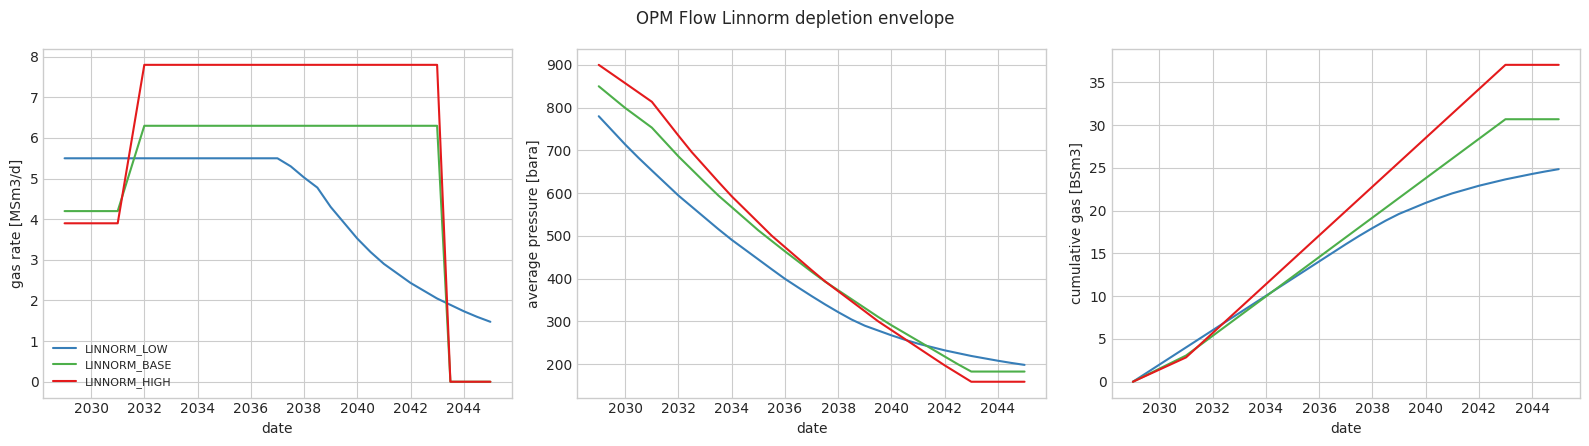

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
linnorm_colors = {
    "LINNORM_LOW": "#377eb8",
    "LINNORM_BASE": "#4daf4a",
    "LINNORM_HIGH": "#e41a1c",
}
for case_name, color in linnorm_colors.items():
    subset = forecasts[forecasts["case"] == case_name]
    axes[0].plot(subset["date"], subset["gas_rate_msm3d"], label=case_name, color=color)
    axes[1].plot(subset["date"], subset["pressure_bara"], color=color)
    axes[2].plot(subset["date"], subset["gas_cum_bsm3"], color=color)
axes[0].set_ylabel("gas rate [MSm3/d]")
axes[1].set_ylabel("average pressure [bara]")
axes[2].set_ylabel("cumulative gas [BSm3]")
for axis in axes:
    axis.set_xlabel("date")
axes[0].legend(fontsize=8)
fig.suptitle("OPM Flow Linnorm depletion envelope")
fig.tight_layout()
plt.show()

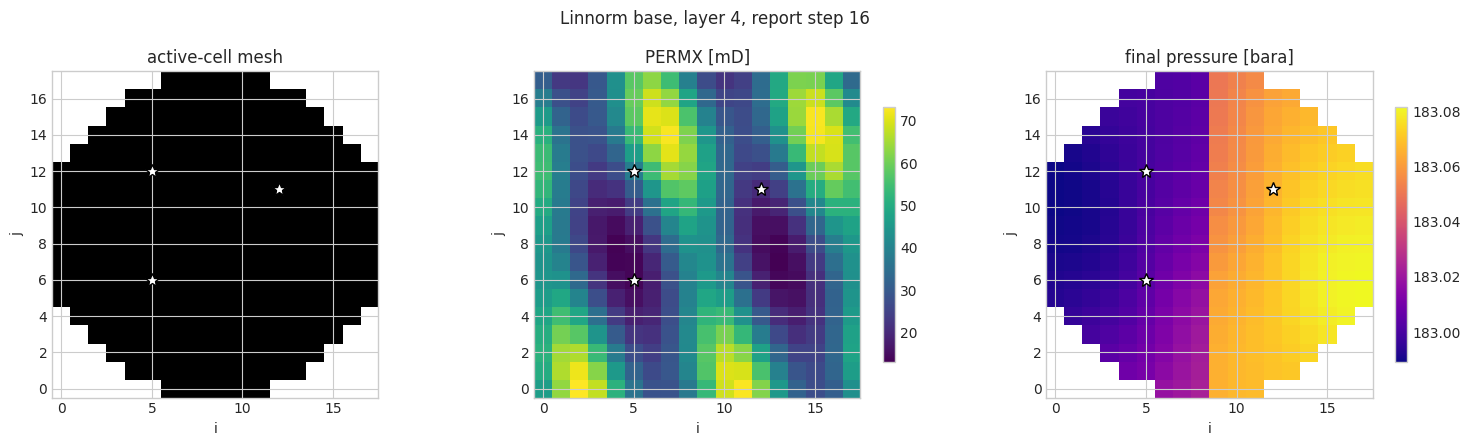

In [28]:
base_name = "LINNORM_BASE"
base_config = CASES[base_name]
base_model = grid_models[base_name]
grid = EGrid(str(deck_paths[base_name].parent / f"{base_name}.EGRID"))
restart = ERst(str(deck_paths[base_name].parent / f"{base_name}.UNRST"))
final_step = int(restart.report_steps[-1])

pressure_cube = np.full(
    (base_config["nx"], base_config["ny"], base_config["nz"]), np.nan
)
sgas_cube = pressure_cube.copy()
for active_index in range(grid.active_cells):
    i, j, k = grid.ijk_from_active_index(active_index)
    pressure_cube[i, j, k] = restart[("PRESSURE", final_step)][active_index]
    sgas_cube[i, j, k] = restart[("SGAS", final_step)][active_index]

middle_layer = base_config["nz"] // 2
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5))
active_map = base_model["arrays"]["ACTNUM"][:, :, middle_layer].T
permeability_map = base_model["arrays"]["PERMX"][:, :, middle_layer].T
pressure_map = pressure_cube[:, :, middle_layer].T
images = [
    axes[0].imshow(active_map, origin="lower", cmap="Greys", vmin=0, vmax=1),
    axes[1].imshow(permeability_map, origin="lower", cmap="viridis"),
    axes[2].imshow(pressure_map, origin="lower", cmap="plasma"),
]
titles = ["active-cell mesh", "PERMX [mD]", "final pressure [bara]"]
for axis, title in zip(axes, titles):
    axis.set_title(title)
    axis.set_xlabel("i")
    axis.set_ylabel("j")
for i, j in base_model["wells"]:
    for axis in axes:
        axis.plot(i - 1, j - 1, "w*", ms=10, mec="black")
fig.colorbar(images[1], ax=axes[1], shrink=0.78)
fig.colorbar(images[2], ax=axes[2], shrink=0.78)
fig.suptitle(f"Linnorm base, layer {middle_layer + 1}, report step {final_step}")
fig.tight_layout()
plt.show()

assert np.nanmin(pressure_cube) > 0.0
assert np.nanmax(sgas_cube) <= 1.0 + 1.0e-8

The white stars are completions. The central low-`MULTX` strip represents compartmentalization,
not a mapped Linnorm fault. The restart plot is read from Flow's binary `UNRST`; it is not
reconstructed from the input deck. That distinction catches indexing, ACTNUM, and output errors.

## 5. Reconstruct time-varying NeqSim well streams

In [29]:
def annual_forecast(case_name, start_year=2029, end_year=2045):
    subset = forecasts[forecasts["case"] == case_name].copy()
    subset = subset.sort_values("date").drop_duplicates("date", keep="last")
    edges = pd.date_range(f"{start_year}-01-01", f"{end_year}-01-01", freq="YS")
    time_series = subset.set_index("date")[["gas_cum_bsm3", "pressure_bara"]]
    edge_frame = (
        time_series.reindex(time_series.index.union(edges))
        .sort_index()
        .interpolate(method="time")
        .reindex(edges)
    )
    edge_frame["gas_cum_bsm3"] = edge_frame["gas_cum_bsm3"].fillna(0.0)
    edge_frame["pressure_bara"] = (
        edge_frame["pressure_bara"].bfill().ffill()
    )
    rows = []
    for index, year in enumerate(range(start_year, end_year)):
        days = (edges[index + 1] - edges[index]).days
        produced_bsm3 = max(
            float(edge_frame.iloc[index + 1]["gas_cum_bsm3"]
                  - edge_frame.iloc[index]["gas_cum_bsm3"]),
            0.0,
        )
        rows.append({
            "year": year,
            "gas_rate_msm3d": produced_bsm3 * 1000.0 / days,
            "pressure_bara": 0.5 * float(
                edge_frame.iloc[index]["pressure_bara"]
                + edge_frame.iloc[index + 1]["pressure_bara"]
            ),
            "gas_cum_bsm3": float(edge_frame.iloc[index + 1]["gas_cum_bsm3"]),
        })
    return pd.DataFrame(rows)

annual_cases = {case_name: annual_forecast(case_name) for case_name in CASES}

snapshot_years = [2029, 2034, 2039, 2044]
well_stream_rows = []
for year in snapshot_years:
    row = annual_cases["LINNORM_BASE"].query("year == @year").iloc[0]
    pressure = max(75.0, 0.72 * row["pressure_bara"])
    fluid = build_fluid("LINNORM", 65.0, pressure)
    stream = Stream(f"Linnorm reconstructed {year}", fluid)
    stream.setFlowRate(float(row["gas_rate_msm3d"]), "MSm3/day")
    stream.run()
    well_stream_rows.append({
        "year": year,
        "Flow_field_rate_MSm3d": row["gas_rate_msm3d"],
        "Flow_mean_pressure_bara": row["pressure_bara"],
        "NeqSim_tree_pressure_bara": pressure,
        "mass_rate_kg_h": float(stream.getFlowRate("kg/hr")),
        "standard_density_kg_Sm3": float(stream.getFluid().getDensity("kg/Sm3")),
        "phase_count": int(stream.getFluid().getNumberOfPhases()),
    })

reconstructed_streams = pd.DataFrame(well_stream_rows)
display(reconstructed_streams)

,year,Flow_field_rate_MSm3d,Flow_mean_pressure_bara,NeqSim_tree_pressure_bara,mass_rate_kg_h,standard_density_kg_Sm3,phase_count
0,2029,4.2,799,575.3,1.41e+05,0.8057,1
1,2034,6.3,540.1,388.9,2.115e+05,0.8057,1
2,2039,6.3,311.3,224.2,2.115e+05,0.8057,1
3,2044,0,182.9,131.7,0,0.8057,2


Flow provides field rate and pressure. NeqSim re-attaches the full E300-derived composition at each
snapshot and converts standard volume to mass with the same EOS used downstream. The 0.72 pressure
factor is an explicit tree-pressure analogue; a real project would pass well-by-well tubing-head
pressure, temperature, water, condensate, and allocation data.

## 6. Subsea production system and flow assurance

In [30]:
PipeBeggsAndBrills = jpype.JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)

route_scenarios = {
    "KRISTIN": {
        "distance_km": float(host_candidates.loc[
            host_candidates["host"] == "KRISTIN", "straight_line_km"
        ].iloc[0]),
        "diameter_m": 0.4572,
        "roughness_m": 4.5e-5,
        "host_inlet_min_bara": 80.0,
        "seabed_C": 4.0,
    },
    "ASGARD": {
        "distance_km": float(host_candidates.loc[
            host_candidates["host"] == "ÅSGARD B", "straight_line_km"
        ].iloc[0]),
        "diameter_m": 0.5080,
        "roughness_m": 4.5e-5,
        "host_inlet_min_bara": 70.0,
        "seabed_C": 4.0,
    },
}

def run_pipeline(host_name, rate_msm3d, inlet_bara=210.0, inlet_C=70.0):
    route = route_scenarios[host_name]
    inlet_fluid = build_fluid("LINNORM", inlet_C, inlet_bara)
    inlet_stream = Stream(f"Linnorm {host_name} pipeline inlet", inlet_fluid)
    inlet_stream.setFlowRate(float(rate_msm3d), "MSm3/day")
    inlet_stream.run()

    pipeline = PipeBeggsAndBrills(f"Linnorm to {host_name}", inlet_stream)
    pipeline.setLength(route["distance_km"] * 1000.0)
    pipeline.setDiameter(route["diameter_m"])
    pipeline.setPipeWallRoughness(route["roughness_m"])
    pipeline.setElevation(0.0)
    pipeline.setNumberOfIncrements(30)
    pipeline.setConstantSurfaceTemperature(route["seabed_C"], "C")
    pipeline.setOuterHeatTransferCoefficient(8.0)
    pipeline.run()
    return pipeline

pipeline_rows = []
pipeline_objects = {}
for host_name in route_scenarios:
    for case_name in ["LINNORM_LOW", "LINNORM_BASE", "LINNORM_HIGH"]:
        peak_rate = float(annual_cases[case_name]["gas_rate_msm3d"].max())
        pipeline = run_pipeline(host_name, peak_rate)
        pipeline_objects[(host_name, case_name)] = pipeline
        pipeline_rows.append({
            "host": host_name,
            "reservoir_case": case_name,
            "rate_MSm3d": peak_rate,
            "length_km": route_scenarios[host_name]["distance_km"],
            "ID_in": route_scenarios[host_name]["diameter_m"] / 0.0254,
            "arrival_bara": float(pipeline.getOutletStream().getPressure("bara")),
            "arrival_C": float(pipeline.getOutletStream().getTemperature("C")),
            "pressure_drop_bar": 210.0 - float(
                pipeline.getOutletStream().getPressure("bara")
            ),
            "phase_count": int(pipeline.getOutletStream().getFluid().getNumberOfPhases()),
        })

pipeline_results = pd.DataFrame(pipeline_rows)
display(pipeline_results)

,host,reservoir_case,rate_MSm3d,length_km,ID_in,arrival_bara,arrival_C,pressure_drop_bar,phase_count
0,KRISTIN,LINNORM_LOW,5.5,62.15,18,206.4,3.984,3.639,1
1,KRISTIN,LINNORM_BASE,6.3,62.15,18,205.2,3.979,4.77,1
2,KRISTIN,LINNORM_HIGH,7.8,62.15,18,202.7,3.967,7.315,1
3,ASGARD,LINNORM_LOW,5.5,73.82,20,207.5,3.989,2.509,1
4,ASGARD,LINNORM_BASE,6.3,73.82,20,206.7,3.986,3.286,1
5,ASGARD,LINNORM_HIGH,7.8,73.82,20,205,3.978,5.028,1


In [31]:
SystemSrkCPAstatoil = jpype.JClass("neqsim.thermo.system.SystemSrkCPAstatoil")

def hydrate_temperature(rate_case="LINNORM_BASE", meg_mass_fraction=0.0):
    fluid = SystemSrkCPAstatoil(273.15 + 10.0, 120.0)
    for component, fraction in fluid_compositions["LINNORM"].items():
        fluid.addComponent(component, fraction)
    fluid.addComponent("water", 0.03)
    if meg_mass_fraction > 0.0:
        fluid.addComponent("MEG", 0.03 * meg_mass_fraction / (1.0 - meg_mass_fraction))
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    fluid.setHydrateCheck(True)
    operations = ThermodynamicOperations(fluid)
    operations.hydrateFormationTemperature()
    return float(fluid.getTemperature("C"))

hydrate_rows = []
for meg_fraction in [0.0, 0.20, 0.40]:
    try:
        hydrate_C = hydrate_temperature(meg_mass_fraction=meg_fraction)
        status = "calculated"
    except Exception as error:
        hydrate_C = np.nan
        status = f"not converged: {str(error)[:90]}"
    hydrate_rows.append({
        "MEG_mass_fraction_scenario": meg_fraction,
        "hydrate_equilibrium_C_at_120_bara": hydrate_C,
        "status": status,
    })
hydrate_screen = pd.DataFrame(hydrate_rows)
display(hydrate_screen)

,MEG_mass_fraction_scenario,hydrate_equilibrium_C_at_120_bara,status
0,0,15.14,calculated
1,0.2,-3.775,calculated
2,0.4,-26.34,calculated


In [32]:
corrosion_rows = []
for host_name in route_scenarios:
    pipeline = pipeline_objects[(host_name, "LINNORM_BASE")]
    try:
        pipeline.setDesignLifeYears(25.0)
        pipeline.setInhibitorEfficiency(0.90)
        pipeline.runCorrosionAnalysis()
        corrosion_rows.append({
            "host": host_name,
            "corrosion_rate_mm_y": float(pipeline.getCorrosionRate()),
            "recommended_material": str(pipeline.getRecommendedMaterial()),
            "corrosion_allowance_mm": float(
                pipeline.getRecommendedCorrosionAllowanceMm()
            ),
            "model": "NeqSim NORSOK screening",
        })
    except Exception as error:
        corrosion_rows.append({
            "host": host_name,
            "corrosion_rate_mm_y": np.nan,
            "recommended_material": "requires master corrosion API",
            "corrosion_allowance_mm": np.nan,
            "model": f"unavailable: {str(error)[:100]}",
        })
corrosion_screen = pd.DataFrame(corrosion_rows)
display(corrosion_screen)

,host,corrosion_rate_mm_y,recommended_material,corrosion_allowance_mm,model
0,KRISTIN,0.4947,"Super 13Cr (UNS S41426, sour service qualified)",0,NeqSim NORSOK screening
1,ASGARD,0.4911,"Super 13Cr (UNS S41426, sour service qualified)",0,NeqSim NORSOK screening


These steady-state pipelines screen route length and diameter; they do not cover terrain slugging,
cooldown, restart, liquid accumulation, wax, erosion, insulation design, or transient hydrate risk.
The hydrate calculation is thermodynamic equilibrium, while the corrosion call is a material-screening
aid. A concept gate therefore requires OLGA/LedaFlow-class transient work, water chemistry, verified
H2S/CO2, and metallurgy qualification even when the steady-state pressure margin is positive.

## 7. NeqSim master multi-area host models

A platform is not one scalar capacity. The current NeqSim Java master can attach a named
`ProcessModel` to a `HostFacility`, inject the combined host-plus-satellite load at an
area-qualified stream, run every area, identify the downstream equipment bottleneck, and restore
the original operating point. This notebook uses three areas: gathering, compression, and treating.

Kristin's published 18 MSm3/d gas capacity is retained. Åsgard B nameplate, compression power,
separator mass rate, and CO2-treatment limits are scenarios because public current equipment margins
were not found. `DIRECT` and `UPGRADED` are therefore concepts, not claims about booked capacity.

In [33]:
ProcessModel = J("neqsim.process.processmodel.ProcessModel")
ProcessSystem = J("neqsim.process.processmodel.ProcessSystem")
Separator = J("neqsim.process.equipment.separator.Separator")
Compressor = J("neqsim.process.equipment.compressor.Compressor")
Cooler = J("neqsim.process.equipment.heatexchanger.Cooler")
CapacityConstraint = J("neqsim.process.equipment.capacity.CapacityConstraint")
ConstraintType = J(
    "neqsim.process.equipment.capacity.CapacityConstraint$ConstraintType"
)
PropertyInitLevel = J(
    "neqsim.process.equipment.stream.Stream$PropertyInitLevel"
)
ProductionProfileSeries = J(
    "neqsim.process.fielddevelopment.tieback.capacity.ProductionProfileSeries"
)
HostTieInPoint = J(
    "neqsim.process.fielddevelopment.tieback.capacity.HostTieInPoint"
)
TieInCapacityPlanner = J(
    "neqsim.process.fielddevelopment.tieback.capacity.TieInCapacityPlanner"
)
AllocationPolicy = J(
    "neqsim.process.fielddevelopment.tieback.capacity.CapacityAllocationPolicy"
)
HoldbackPolicy = J(
    "neqsim.process.fielddevelopment.tieback.capacity.HoldbackPolicy"
)

HOST_CONCEPTS = {
    "KRISTIN_DIRECT": {
        "host": "KRISTIN", "host_case": "KRISTIN_HOST", "gas_capacity": 18.0,
        "separator_kg_h": 620_000.0, "compression_MW": 12.0,
        "co2_capacity_kg_h": 35_000.0, "export_bara": 150.0,
        "route_factor": 1.12, "upgrade_capex_MUSD": 0.0,
        "capacity_class": "published gas; equipment ANALOGUE",
    },
    "KRISTIN_UPGRADED": {
        "host": "KRISTIN", "host_case": "KRISTIN_HOST", "gas_capacity": 21.0,
        "separator_kg_h": 780_000.0, "compression_MW": 20.0,
        "co2_capacity_kg_h": 70_000.0, "export_bara": 150.0,
        "route_factor": 1.12, "upgrade_capex_MUSD": 450.0,
        "capacity_class": "all upgrade increments SCENARIO",
    },
    "ASGARD_DIRECT": {
        "host": "ASGARD", "host_case": "ASGARD_HOST", "gas_capacity": 30.0,
        "separator_kg_h": 920_000.0, "compression_MW": 45.0,
        "co2_capacity_kg_h": 75_000.0, "export_bara": 150.0,
        "route_factor": 1.15, "upgrade_capex_MUSD": 0.0,
        "capacity_class": "all equipment/nameplate ANALOGUE",
    },
    "ASGARD_UPGRADED": {
        "host": "ASGARD", "host_case": "ASGARD_HOST", "gas_capacity": 36.0,
        "separator_kg_h": 1_150_000.0, "compression_MW": 60.0,
        "co2_capacity_kg_h": 120_000.0, "export_bara": 150.0,
        "route_factor": 1.15, "upgrade_capex_MUSD": 400.0,
        "capacity_class": "all equipment/nameplate SCENARIO",
    },
}
display(pd.DataFrame(HOST_CONCEPTS).T)

,host,host_case,gas_capacity,separator_kg_h,compression_MW,co2_capacity_kg_h,export_bara,route_factor,upgrade_capex_MUSD,capacity_class
KRISTIN_DIRECT,KRISTIN,KRISTIN_HOST,18,6.2e+05,12,3.5e+04,150,1.12,0,published gas; equipment ANALOGUE
KRISTIN_UPGRADED,KRISTIN,KRISTIN_HOST,21,7.8e+05,20,7e+04,150,1.12,450,all upgrade increments SCENARIO
ASGARD_DIRECT,ASGARD,ASGARD_HOST,30,9.2e+05,45,7.5e+04,150,1.15,0,all equipment/nameplate ANALOGUE
ASGARD_UPGRADED,ASGARD,ASGARD_HOST,36,1.15e+06,60,1.2e+05,150,1.15,400,all equipment/nameplate SCENARIO


In [34]:
def composition_mass_fraction(composition, component_name):
    trial = SystemPrEos(303.15, 70.0)
    for component, fraction in composition.items():
        trial.addComponent(component, fraction)
    trial.setMixingRule("classic")
    trial.init(0)
    component_molar_mass = 0.0440095 if component_name == "CO2" else 0.0340809
    return composition.get(component_name, 0.0) * component_molar_mass / trial.getMolarMass()

def blend_composition(host_fluid, host_rate, satellite_rate):
    total = max(host_rate + satellite_rate, 1.0e-12)
    all_components = set(fluid_compositions[host_fluid]) | set(
        fluid_compositions["LINNORM"]
    )
    return {
        component: (
            host_rate * fluid_compositions[host_fluid].get(component, 0.0)
            + satellite_rate * fluid_compositions["LINNORM"].get(component, 0.0)
        ) / total
        for component in all_components
    }

supplier_references = []

def add_constraint(equipment, name, unit, design_value, value_function):
    supplier = jpype.JProxy(
        "java.util.function.DoubleSupplier", dict(getAsDouble=value_function)
    )
    supplier_references.append(supplier)
    constraint = CapacityConstraint(name, unit, ConstraintType.HARD)
    constraint.setDesignValue(float(design_value))
    constraint.setValueSupplier(supplier)
    equipment.addCapacityConstraint(constraint)
    return constraint

def build_host_process(concept_name):
    concept = HOST_CONCEPTS[concept_name]
    host_annual = annual_cases[concept["host_case"]]
    satellite_annual = annual_cases["LINNORM_BASE"]
    host_peak = float(host_annual["gas_rate_msm3d"].max())
    satellite_peak = float(satellite_annual["gas_rate_msm3d"].max())
    host_fluid_name = "KRISTIN" if concept["host"] == "KRISTIN" else "ASGARD"
    blend = blend_composition(host_fluid_name, host_peak, satellite_peak)

    fluid = SystemPrEos(303.15, 70.0)
    for component, fraction in blend.items():
        fluid.addComponent(component, fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)

    feed = Stream(f"{concept_name} Host Feed", fluid)
    feed.setFlowRate(
        host_peak * standard_density["LINNORM"] * 1.0e6 / 24.0, "kg/hr"
    )
    feed.run()

    gathering = ProcessSystem(f"{concept_name} gathering")
    gathering.add(feed)

    inlet_separator = Separator(f"{concept_name} Inlet Separator", feed)
    compressor = Compressor(
        f"{concept_name} Export Compressor", inlet_separator.getGasOutStream()
    )
    compressor.setOutletPressure(concept["export_bara"], "bara")
    compressor.setIsentropicEfficiency(0.76)
    cooler = Cooler(f"{concept_name} Export Cooler", compressor.getOutletStream())
    cooler.setOutTemperature(35.0, "C")
    compression = ProcessSystem(f"{concept_name} compression")
    compression.add(inlet_separator)
    compression.add(compressor)
    compression.add(cooler)

    treating_separator = Separator(
        f"{concept_name} CO2 Treating", cooler.getOutletStream()
    )
    treating = ProcessSystem(f"{concept_name} treating")
    treating.add(treating_separator)

    model = ProcessModel()
    model.add("gathering", gathering)
    model.add("compression", compression)
    model.add("treating", treating)

    co2_mass_fraction = composition_mass_fraction(blend, "CO2")
    add_constraint(
        inlet_separator,
        "inlet mass load",
        "kg/hr",
        concept["separator_kg_h"],
        lambda feed=feed: float(feed.getFlowRate("kg/hr")),
    )
    add_constraint(
        compressor,
        "compression power",
        "MW",
        concept["compression_MW"],
        lambda compressor=compressor: float(compressor.getPower("MW")),
    )
    add_constraint(
        treating_separator,
        "CO2 treatment load",
        "kg/hr",
        concept["co2_capacity_kg_h"],
        lambda feed=feed, fraction=co2_mass_fraction: (
            float(feed.getFlowRate("kg/hr")) * fraction
        ),
    )

    model.run()
    model.resolveStreamReference(f"gathering::{concept_name} Host Feed")
    light_count = model.setPropertyInitLevel(PropertyInitLevel.DENSITY_ONLY)
    full_count = model.setPropertyInitLevel(PropertyInitLevel.FULL)
    model.run()

    host_row = host_candidates.query(
        "host == 'KRISTIN'" if concept["host"] == "KRISTIN" else "host == 'ÅSGARD B'"
    ).iloc[0]
    facility = (
        HostFacility.builder(concept_name)
        .operator("Equinor")
        .location(float(host_row["latitude"]), float(host_row["longitude"]))
        .waterDepth(float(host_row["water_depth_m"]))
        .gasCapacity(concept["gas_capacity"])
        .minTieInPressure(route_scenarios[concept["host"]]["host_inlet_min_bara"])
        .maxTieInPressure(220.0)
        .processModel(model)
        .build()
    )
    return {
        "facility": facility,
        "model": model,
        "feed": feed,
        "compressor": compressor,
        "co2_mass_fraction": co2_mass_fraction,
        "light_count": int(light_count),
        "full_count": int(full_count),
    }

host_processes = {
    concept_name: build_host_process(concept_name) for concept_name in HOST_CONCEPTS
}

process_baseline = []
for concept_name, bundle in host_processes.items():
    model = bundle["model"]
    bottleneck = model.findBottleneck()
    process_baseline.append({
        "concept": concept_name,
        "light_init_streams": bundle["light_count"],
        "full_init_streams": bundle["full_count"],
        "bottleneck_equipment": str(bottleneck.getEquipment().getName()),
        "utilization": float(bottleneck.getUtilization()),
        "hard_limit_exceeded": bool(model.isAnyHardLimitExceeded()),
        "validation": str(model.validateAll()),
        "mass_balance": str(model.checkMassBalance()),
    })
process_baseline = pd.DataFrame(process_baseline)
display(process_baseline[[
    "concept", "light_init_streams", "full_init_streams",
    "bottleneck_equipment", "utilization", "hard_limit_exceeded"
]])

,concept,light_init_streams,full_init_streams,bottleneck_equipment,utilization,hard_limit_exceeded
0,KRISTIN_DIRECT,9,9,KRISTIN_DIRECT CO2 Treating,0.3107,False
1,KRISTIN_UPGRADED,9,9,KRISTIN_UPGRADED CO2 Treating,0.1554,False
2,ASGARD_DIRECT,9,9,ASGARD_DIRECT CO2 Treating,0.4544,False
3,ASGARD_UPGRADED,9,9,ASGARD_UPGRADED Inlet Separator,0.3547,False


`DENSITY_ONLY` demonstrates the master stream-property initialization control for large capacity
sweeps; `FULL` is restored before compressor and treating calculations. The notebook also invokes
plant-wide validation, mass-balance diagnostics, area-qualified stream resolution, utilization JSON,
hard-limit checks, and bottleneck search. Those diagnostics are exported later rather than hidden.

## 8. Host allocation, holdback, deferment, and utilization

In [35]:
def java_profile(name, annual):
    profile = ProductionProfileSeries(name)
    for row in annual.itertuples():
        profile.addPeriod(
            int(row.year), float(max(row.gas_rate_msm3d, 0.0)), 0.0, 0.0, 0.0
        )
    return profile

def run_capacity_plan(
    concept_name,
    allocation=AllocationPolicy.BASE_FIRST,
    holdback=HoldbackPolicy.DEFER_TO_LATER_YEARS,
    linnorm_case="LINNORM_BASE",
):
    concept = HOST_CONCEPTS[concept_name]
    bundle = host_processes[concept_name]
    base_profile = java_profile(
        f"{concept_name} host base", annual_cases[concept["host_case"]]
    )
    satellite_profile = java_profile(
        f"{linnorm_case} satellite", annual_cases[linnorm_case]
    )
    mass_factor = standard_density["LINNORM"] * 1.0e6 / 24.0
    tie_point = HostTieInPoint(
        f"gathering::{concept_name} Host Feed", "kg/hr"
    ).setGasToProcessRateFactor(mass_factor)
    original_rate = float(bundle["feed"].getFlowRate("kg/hr"))
    planner = (
        TieInCapacityPlanner(bundle["facility"])
        .setHostProductionProfile(base_profile)
        .setSatelliteProductionProfile(satellite_profile)
        .setAllocationPolicy(allocation)
        .setHoldbackPolicy(holdback)
        .setTieInPoint(tie_point)
        .setProcessUtilizationLimit(0.95)
        .setDefaultCommodityValues(200_000.0, 0.0, 0.0, 0.0)
        .setDiscountRate(0.08)
        .setDefaultDebottleneckCapexMusd(concept["upgrade_capex_MUSD"])
    )
    result = planner.run()
    restored_rate = float(bundle["feed"].getFlowRate("kg/hr"))
    assert abs(restored_rate - original_rate) < max(1.0e-5, original_rate * 1.0e-8)
    return result

capacity_results = {}
period_rows = []
for concept_name in HOST_CONCEPTS:
    result = run_capacity_plan(concept_name)
    capacity_results[concept_name] = result
    for period in result.getPeriodResults():
        period_rows.append({
            "concept": concept_name,
            "year": int(period.getYear()),
            "host_request_MSm3d": float(period.getBaseRequest().getGasRateMSm3d()),
            "satellite_request_MSm3d": float(
                period.getSatelliteRequest().getGasRateMSm3d()
            ),
            "accepted_MSm3d": float(
                period.getAcceptedSatellite().getGasRateMSm3d()
            ),
            "held_back_MSm3d": float(
                period.getHeldBackSatellite().getGasRateMSm3d()
            ),
            "deferred_in_MSm3d": float(
                period.getDeferredIntoPeriod().getGasRateMSm3d()
            ),
            "deferred_out_MSm3d": float(
                period.getDeferredToNextPeriod().getGasRateMSm3d()
            ),
            "allocation_fraction": float(period.getSatelliteAllocationScale()),
            "nameplate_bottleneck": str(period.getNameplateBottleneck()),
            "process_bottleneck": str(period.getProcessBottleneck()),
            "process_utilization": float(period.getProcessBottleneckUtilization()),
            "primary_bottleneck": str(period.getPrimaryBottleneck()),
            "deferred_value_NPV_MUSD": float(period.getDeferredValueNpvMusd()),
        })

capacity_periods = pd.DataFrame(period_rows)
capacity_summary = pd.DataFrame([
    {
        "concept": concept_name,
        "accepted_BSm3": float(result.getTotalAcceptedGasMSm3()) / 1000.0,
        "held_back_BSm3": float(result.getTotalHeldBackGasMSm3()) / 1000.0,
        "deferred_value_NPV_MUSD": float(result.getTotalDeferredValueNpvMusd()),
        "primary_bottleneck": str(result.getPrimaryBottleneck()),
        "has_holdback": bool(result.hasHoldback()),
    }
    for concept_name, result in capacity_results.items()
])
display(capacity_summary)

,concept,accepted_BSm3,held_back_BSm3,deferred_value_NPV_MUSD,primary_bottleneck,has_holdback
0,KRISTIN_DIRECT,30.66,1.727,250.6,treating::KRISTIN_DIRECT CO2 Treating,True
1,KRISTIN_UPGRADED,30.66,0,0,treating::KRISTIN_UPGRADED CO2 Treating,False
2,ASGARD_DIRECT,30.66,0,0,treating::ASGARD_DIRECT CO2 Treating,False
3,ASGARD_UPGRADED,30.66,0,0,compression::ASGARD_UPGRADED Inlet Separator,False


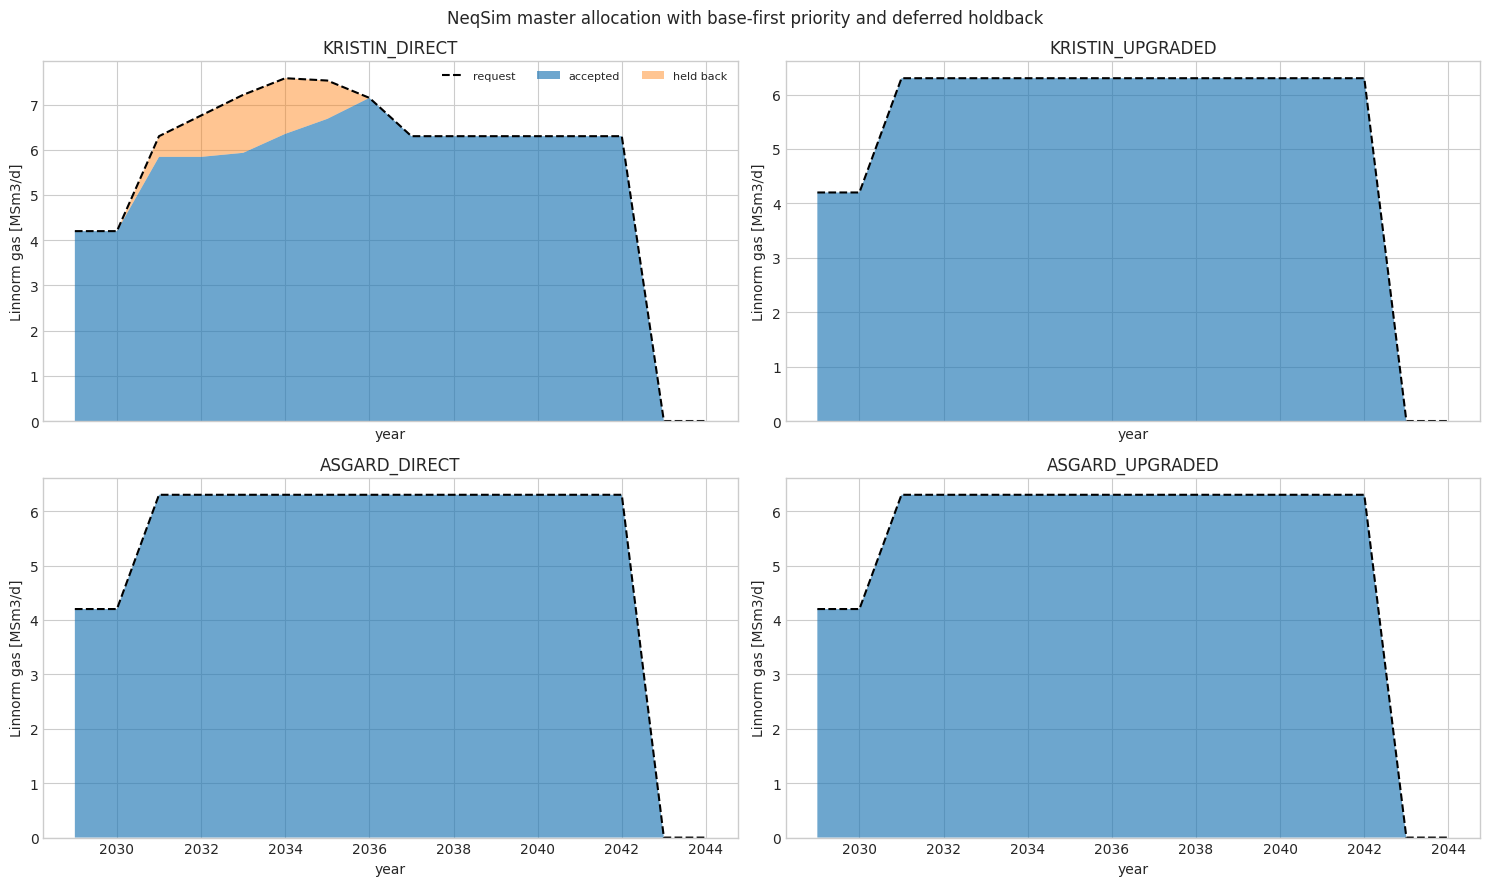

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
for axis, concept_name in zip(axes.ravel(), HOST_CONCEPTS):
    subset = capacity_periods.query("concept == @concept_name")
    axis.plot(subset["year"], subset["satellite_request_MSm3d"], "k--", label="request")
    axis.fill_between(
        subset["year"], 0.0, subset["accepted_MSm3d"], alpha=0.65, label="accepted"
    )
    axis.fill_between(
        subset["year"], subset["accepted_MSm3d"],
        subset["accepted_MSm3d"] + subset["held_back_MSm3d"],
        alpha=0.45, label="held back"
    )
    axis.set_title(concept_name)
    axis.set_ylabel("Linnorm gas [MSm3/d]")
    axis.set_xlabel("year")
    axis.set_ylim(bottom=0)
axes[0, 0].legend(ncol=3, fontsize=8)
fig.suptitle("NeqSim master allocation with base-first priority and deferred holdback")
fig.tight_layout()
plt.show()

In [37]:
policy_rows = []
for allocation_name in ["BASE_FIRST", "SATELLITE_FIRST", "PRO_RATA", "VALUE_WEIGHTED"]:
    allocation = getattr(AllocationPolicy, allocation_name)
    for holdback_name in ["CURTAIL", "DEFER_TO_LATER_YEARS"]:
        holdback = getattr(HoldbackPolicy, holdback_name)
        result = run_capacity_plan(
            "KRISTIN_DIRECT", allocation=allocation, holdback=holdback
        )
        policy_rows.append({
            "allocation": allocation_name,
            "holdback": holdback_name,
            "accepted_BSm3": float(result.getTotalAcceptedGasMSm3()) / 1000.0,
            "held_back_BSm3": float(result.getTotalHeldBackGasMSm3()) / 1000.0,
            "deferred_value_NPV_MUSD": float(result.getTotalDeferredValueNpvMusd()),
            "primary_bottleneck": str(result.getPrimaryBottleneck()),
        })
policy_sensitivity = pd.DataFrame(policy_rows)
display(policy_sensitivity)

,allocation,holdback,accepted_BSm3,held_back_BSm3,deferred_value_NPV_MUSD,primary_bottleneck
0,BASE_FIRST,CURTAIL,30.19,0.468,74.85,treating::KRISTIN_DIRECT CO2 Treating
1,BASE_FIRST,DEFER_TO_LATER_YEARS,30.66,1.727,250.6,treating::KRISTIN_DIRECT CO2 Treating
2,SATELLITE_FIRST,CURTAIL,30.19,0.468,74.85,treating::KRISTIN_DIRECT CO2 Treating
3,SATELLITE_FIRST,DEFER_TO_LATER_YEARS,30.66,1.727,250.6,treating::KRISTIN_DIRECT CO2 Treating
4,PRO_RATA,CURTAIL,30.19,0.468,74.85,treating::KRISTIN_DIRECT CO2 Treating
5,PRO_RATA,DEFER_TO_LATER_YEARS,30.66,1.727,250.6,treating::KRISTIN_DIRECT CO2 Treating
6,VALUE_WEIGHTED,CURTAIL,30.19,0.468,74.85,treating::KRISTIN_DIRECT CO2 Treating
7,VALUE_WEIGHTED,DEFER_TO_LATER_YEARS,30.66,1.727,250.6,treating::KRISTIN_DIRECT CO2 Treating


Base-first is the physical default because a satellite normally cannot displace committed host
production without an agreement. `SATELLITE_FIRST`, `PRO_RATA`, and `VALUE_WEIGHTED` expose the value
of different access rules; they are not proposed contract terms. Deferred gas is re-tested against
later ullage, so “holdback” is not automatically permanent loss.

## 9. Detailed maximum-load separation, compression, cooling, and amine treating

In [38]:
SimpleAmineAbsorber = J(
    "neqsim.process.equipment.absorber.SimpleAmineAbsorber"
)

max_row = capacity_periods.loc[capacity_periods["accepted_MSm3d"].idxmax()]
max_concept = str(max_row["concept"])
max_total_rate = float(max_row["host_request_MSm3d"] + max_row["accepted_MSm3d"])
max_host_fluid = "KRISTIN" if max_concept.startswith("KRISTIN") else "ASGARD"
max_blend = blend_composition(
    max_host_fluid,
    float(max_row["host_request_MSm3d"]),
    float(max_row["accepted_MSm3d"]),
)

max_fluid = SystemPrEos(273.15 + 30.0, 70.0)
for component, fraction in max_blend.items():
    max_fluid.addComponent(component, fraction)
max_fluid.setMixingRule("classic")
max_fluid.setMultiPhaseCheck(True)

maximum_feed = Stream("Maximum combined host feed", max_fluid)
maximum_feed.setFlowRate(max_total_rate, "MSm3/day")
inlet_separator = Separator("Maximum-load inlet separator", maximum_feed)
export_compressor = Compressor(
    "Maximum-load export compressor", inlet_separator.getGasOutStream()
)
export_compressor.setOutletPressure(150.0, "bara")
export_compressor.setIsentropicEfficiency(0.76)
export_cooler = Cooler(
    "Maximum-load aftercooler", export_compressor.getOutletStream()
)
export_cooler.setOutTemperature(35.0, "C")

lean_amine_fluid = SystemSrkCPAstatoil(273.15 + 40.0, 70.0)
lean_amine_fluid.addComponent("water", 0.70)
lean_amine_fluid.addComponent("MDEA", 0.30)
lean_amine_fluid.setMixingRule(10)
lean_amine = Stream("Lean MDEA", lean_amine_fluid)
lean_amine.setFlowRate(1_200_000.0, "kg/hr")

amine_absorber = SimpleAmineAbsorber(
    "Maximum-load MDEA contactor", export_cooler.getOutletStream()
)
amine_absorber.setLeanAmineInStream(lean_amine)
amine_absorber.setCO2RemovalEfficiency(0.90)

maximum_process = ProcessSystem("Maximum-load concept process")
maximum_process.add(maximum_feed)
maximum_process.add(inlet_separator)
maximum_process.add(export_compressor)
maximum_process.add(export_cooler)
maximum_process.add(lean_amine)
maximum_process.add(amine_absorber)
maximum_process.run()

treated_gas = amine_absorber.getSweetGasOutStream()
treated_composition = {
    str(treated_gas.getFluid().getPhase(0).getComponent(i).getName()): float(
        treated_gas.getFluid().getPhase(0).getComponent(i).getx()
    )
    for i in range(treated_gas.getFluid().getPhase(0).getNumberOfComponents())
}
max_load_results = pd.DataFrame([{
    "concept": max_concept,
    "year": int(max_row["year"]),
    "combined_rate_MSm3d": max_total_rate,
    "feed_CO2_molpct": 100.0 * max_blend["CO2"],
    "treated_CO2_molpct": 100.0 * treated_composition.get("CO2", np.nan),
    "compressor_power_MW": float(export_compressor.getPower("MW")),
    "separator_liquid_kg_h": float(
        inlet_separator.getLiquidOutStream().getFlowRate("kg/hr")
    ),
    "treated_gas_kg_h": float(treated_gas.getFlowRate("kg/hr")),
}])
display(max_load_results)

,concept,year,combined_rate_MSm3d,feed_CO2_molpct,treated_CO2_molpct,compressor_power_MW,separator_liquid_kg_h,treated_gas_kg_h
0,KRISTIN_DIRECT,2036,8.643,6.376,0.6797,9.963,2.445e+04,2.462e+05


The maximum accepted load is re-run through real thermodynamic unit operations. The simple amine
absorber is a screening model with an imposed removal efficiency; it is not a column design. A
concept-select study needs solvent circulation/rich loading, heat-stable salts, reboiler duty,
emissions, dehydration specification, hydrocarbon co-absorption, and regeneration hydraulics.

## 10. Pre-tax screening economics and holdback value

Economics are intentionally simple and completely exposed. They compare concepts on a common basis;
they are not a tariff model. Gas netback, liquids value, well cost, subsea cost, route cost, host
modifications, availability, tax, abandonment, and schedule are all material. Currency is real 2026
USD and results are pre-tax NPV at 8%.

In [39]:
ECONOMIC_ASSUMPTIONS = {
    "gas_price_USD_per_Sm3": 0.20,
    "gas_variable_opex_USD_per_Sm3": 0.035,
    "oil_netback_USD_per_bbl": 50.0,
    "discount_rate": 0.08,
    "well_MUSD_each": 180.0,
    "well_count": 3,
    "subsea_template_MUSD": 320.0,
    "flowline_MUSD_per_km": 4.0,
    "umbilical_MUSD_per_km": 1.5,
    "host_tie_in_MUSD": 220.0,
    "controls_and_contingency_MUSD": 140.0,
    "public_oil_MSm3": float(resources["dscRecoverableOil"]),
    "public_gas_BSm3": float(resources["dscRecoverableGas"]),
}

def concept_capex(concept_name):
    concept = HOST_CONCEPTS[concept_name]
    route = route_scenarios[concept["host"]]["distance_km"] * concept["route_factor"]
    return (
        ECONOMIC_ASSUMPTIONS["well_MUSD_each"] * ECONOMIC_ASSUMPTIONS["well_count"]
        + ECONOMIC_ASSUMPTIONS["subsea_template_MUSD"]
        + ECONOMIC_ASSUMPTIONS["flowline_MUSD_per_km"] * route
        + ECONOMIC_ASSUMPTIONS["umbilical_MUSD_per_km"] * route
        + ECONOMIC_ASSUMPTIONS["host_tie_in_MUSD"]
        + ECONOMIC_ASSUMPTIONS["controls_and_contingency_MUSD"]
        + concept["upgrade_capex_MUSD"]
    )

def economic_from_profile(concept_name, profile, assumptions=ECONOMIC_ASSUMPTIONS):
    profile = profile.sort_values("year").copy()
    profile["accepted_gas_MSm3"] = profile["accepted_MSm3d"] * 365.25
    oil_m3_per_gas_MSm3 = (
        assumptions["public_oil_MSm3"] * 1.0e6
        / (assumptions["public_gas_BSm3"] * 1000.0)
    )
    profile["oil_bbl"] = (
        profile["accepted_gas_MSm3"] * oil_m3_per_gas_MSm3 * 6.28981
    )
    gas_margin_MUSD = profile["accepted_gas_MSm3"] * (
        assumptions["gas_price_USD_per_Sm3"]
        - assumptions["gas_variable_opex_USD_per_Sm3"]
    )
    oil_margin_MUSD = profile["oil_bbl"] * assumptions["oil_netback_USD_per_bbl"] / 1.0e6
    profile["cash_flow_MUSD"] = gas_margin_MUSD + oil_margin_MUSD
    first_year = int(profile["year"].min())
    discount = (1.0 + assumptions["discount_rate"]) ** (profile["year"] - first_year + 1)
    pv_revenue = float(np.sum(profile["cash_flow_MUSD"] / discount))
    capex = concept_capex(concept_name)
    return {
        "concept": concept_name,
        "route_km_screen": (
            route_scenarios[HOST_CONCEPTS[concept_name]["host"]]["distance_km"]
            * HOST_CONCEPTS[concept_name]["route_factor"]
        ),
        "CAPEX_MUSD": capex,
        "accepted_gas_BSm3": float(profile["accepted_gas_MSm3"].sum() / 1000.0),
        "screen_oil_MMbbl": float(profile["oil_bbl"].sum() / 1.0e6),
        "PV_margin_MUSD": pv_revenue,
        "NPV8_MUSD": pv_revenue - capex,
    }

economic_rows = []
for concept_name in HOST_CONCEPTS:
    profile = capacity_periods.query("concept == @concept_name")
    economic_rows.append(economic_from_profile(concept_name, profile))
economics = pd.DataFrame(economic_rows).sort_values("NPV8_MUSD", ascending=False)
display(economics)

,concept,route_km_screen,CAPEX_MUSD,accepted_gas_BSm3,screen_oil_MMbbl,PV_margin_MUSD,NPV8_MUSD
0,KRISTIN_DIRECT,69.61,"1,603",30.68,4.319,"3,014","1,411"
2,ASGARD_DIRECT,84.89,"1,687",30.68,4.319,"3,028","1,341"
1,KRISTIN_UPGRADED,69.61,"2,053",30.68,4.319,"3,028",975.5
3,ASGARD_UPGRADED,84.89,"2,087",30.68,4.319,"3,028",941.5


For year $t$, the calculation is:

$$NPV_8=-CAPEX+\sum_t\frac{V_{g,t}(p_g-o_g)+V_{o,t}n_o}{(1+0.08)^t}$$

The oil term distributes SODIR's public recoverable oil/gas ratio over accepted gas. It does not
come from the dry-gas Flow model and must be replaced by a compositional forecast before sanction.

## 11. Coupled uncertainty: value, facility loads, exceedance probability, and drivers

In [40]:
def approximate_realization(concept_name, draw_id):
    concept = HOST_CONCEPTS[concept_name]
    host_profile = annual_cases[concept["host_case"]].copy()
    satellite_profile = annual_cases["LINNORM_BASE"].copy()

    resource_scale = RNG.triangular(0.82, 1.0, 1.18)
    deliverability_scale = RNG.lognormal(mean=-0.5 * 0.16 ** 2, sigma=0.16)
    host_load_scale = np.clip(RNG.normal(1.0, 0.10), 0.72, 1.30)
    gas_capacity_scale = np.clip(RNG.normal(1.0, 0.08), 0.78, 1.22)
    co2_capacity_scale = np.clip(RNG.lognormal(-0.5 * 0.22 ** 2, 0.22), 0.55, 1.65)
    availability = np.clip(RNG.beta(24.0, 2.0), 0.75, 0.995)
    capex_scale = RNG.triangular(0.85, 1.0, 1.35)
    gas_price = np.clip(RNG.normal(0.20, 0.045), 0.08, 0.36)
    opex = np.clip(RNG.normal(0.035, 0.009), 0.015, 0.075)

    host_fluid = "KRISTIN" if concept["host"] == "KRISTIN" else "ASGARD"
    host_co2_fraction = composition_mass_fraction(fluid_compositions[host_fluid], "CO2")
    satellite_co2_fraction = composition_mass_fraction(
        fluid_compositions["LINNORM"], "CO2"
    )
    host_mass_factor = standard_density[host_fluid] * 1.0e6 / 24.0
    satellite_mass_factor = standard_density["LINNORM"] * 1.0e6 / 24.0

    requested = satellite_profile["gas_rate_msm3d"].to_numpy() * deliverability_scale
    host_rate = host_profile["gas_rate_msm3d"].to_numpy() * host_load_scale
    gas_limit = np.maximum(
        concept["gas_capacity"] * gas_capacity_scale - host_rate, 0.0
    )
    host_co2_load = host_rate * host_mass_factor * host_co2_fraction
    co2_limit = np.maximum(
        (
            concept["co2_capacity_kg_h"] * co2_capacity_scale - host_co2_load
        ) / max(satellite_mass_factor * satellite_co2_fraction, 1.0e-9),
        0.0,
    )
    accepted = np.minimum(requested, np.minimum(gas_limit, co2_limit)) * availability

    target_volume = (
        ECONOMIC_ASSUMPTIONS["public_gas_BSm3"] * 1000.0 * resource_scale
    )
    cumulative = 0.0
    for index in range(len(accepted)):
        remaining = max(target_volume - cumulative, 0.0)
        accepted[index] = min(accepted[index], remaining / 365.25)
        cumulative += accepted[index] * 365.25

    years = satellite_profile["year"].to_numpy()
    annual_volume = accepted * 365.25
    margin = annual_volume * (gas_price - opex)
    discount = (1.0 + ECONOMIC_ASSUMPTIONS["discount_rate"]) ** (
        years - years.min() + 1
    )
    capex = concept_capex(concept_name) * capex_scale
    npv = float(np.sum(margin / discount) - capex)

    gas_utilization = (host_rate + accepted) / (
        concept["gas_capacity"] * gas_capacity_scale
    )
    co2_utilization = (
        host_co2_load + accepted * satellite_mass_factor * satellite_co2_fraction
    ) / (concept["co2_capacity_kg_h"] * co2_capacity_scale)
    requested_co2_util = (
        host_co2_load + requested * satellite_mass_factor * satellite_co2_fraction
    ) / (concept["co2_capacity_kg_h"] * co2_capacity_scale)
    exceedance = bool(
        np.any(host_rate + requested > concept["gas_capacity"] * gas_capacity_scale)
        or np.any(requested_co2_util > 1.0)
    )
    return {
        "concept": concept_name,
        "draw": draw_id,
        "resource_scale": resource_scale,
        "deliverability_scale": deliverability_scale,
        "host_load_scale": host_load_scale,
        "gas_capacity_scale": gas_capacity_scale,
        "co2_capacity_scale": co2_capacity_scale,
        "availability": availability,
        "capex_scale": capex_scale,
        "gas_price_USD_Sm3": gas_price,
        "opex_USD_Sm3": opex,
        "NPV8_MUSD": npv,
        "accepted_BSm3": cumulative / 1000.0,
        "held_back_BSm3": max(float(np.sum(requested * 365.25) / 1000.0 - cumulative), 0.0),
        "max_gas_utilization": float(np.max(gas_utilization)),
        "max_CO2_utilization": float(np.max(co2_utilization)),
        "capacity_exceeded_if_unconstrained": exceedance,
    }

uncertainty = pd.DataFrame([
    approximate_realization(concept_name, draw_id)
    for concept_name in HOST_CONCEPTS
    for draw_id in range(300)
])
print("Coupled uncertainty realizations:", len(uncertainty))

Coupled uncertainty realizations: 1200


In [41]:
uncertainty_summary_rows = []
representative_rows = []
for concept_name, subset in uncertainty.groupby("concept"):
    quantiles = subset[[
        "NPV8_MUSD", "max_gas_utilization", "max_CO2_utilization", "accepted_BSm3"
    ]].quantile([0.10, 0.50, 0.90])
    uncertainty_summary_rows.append({
        "concept": concept_name,
        "P10_NPV8_MUSD": quantiles.loc[0.10, "NPV8_MUSD"],
        "P50_NPV8_MUSD": quantiles.loc[0.50, "NPV8_MUSD"],
        "P90_NPV8_MUSD": quantiles.loc[0.90, "NPV8_MUSD"],
        "Q10_max_gas_util": quantiles.loc[0.10, "max_gas_utilization"],
        "Q50_max_gas_util": quantiles.loc[0.50, "max_gas_utilization"],
        "Q90_max_gas_util": quantiles.loc[0.90, "max_gas_utilization"],
        "Q90_max_CO2_util": quantiles.loc[0.90, "max_CO2_utilization"],
        "capacity_exceedance_probability": subset[
            "capacity_exceeded_if_unconstrained"
        ].mean(),
    })
    for label, probability in [("P10", 0.10), ("P50", 0.50), ("P90", 0.90)]:
        target = subset["NPV8_MUSD"].quantile(probability)
        representative = subset.loc[(subset["NPV8_MUSD"] - target).abs().idxmin()].copy()
        row = representative.to_dict()
        row["representative"] = label
        representative_rows.append(row)

uncertainty_summary = pd.DataFrame(uncertainty_summary_rows)
representative_cases = pd.DataFrame(representative_rows)
display(uncertainty_summary.sort_values("P50_NPV8_MUSD", ascending=False))
display(representative_cases[[
    "concept", "representative", "draw", "NPV8_MUSD", "resource_scale",
    "deliverability_scale", "host_load_scale", "co2_capacity_scale", "capex_scale"
]])

,concept,P10_NPV8_MUSD,P50_NPV8_MUSD,P90_NPV8_MUSD,Q10_max_gas_util,Q50_max_gas_util,Q90_max_gas_util,Q90_max_CO2_util,capacity_exceedance_probability
0,ASGARD_DIRECT,-362.7,758.1,"1,846",0.5033,0.5814,0.6779,0.9649,0.2367
2,KRISTIN_DIRECT,-288.2,614.2,"1,686",0.3609,0.4268,0.522,0.9729,0.64
3,KRISTIN_UPGRADED,-651.2,447.3,"1,648",0.3424,0.4026,0.483,0.7468,0.003333
1,ASGARD_UPGRADED,-728.9,271.5,"1,384",0.4268,0.5013,0.5749,0.6596,0.003333


,concept,representative,draw,NPV8_MUSD,resource_scale,deliverability_scale,host_load_scale,co2_capacity_scale,capex_scale
0,ASGARD_DIRECT,P10,267,-362.6,0.8696,1.12,0.9389,0.8931,0.9948
1,ASGARD_DIRECT,P50,53,751.3,0.9817,1.147,0.9255,0.836,1.04
2,ASGARD_DIRECT,P90,286,"1,844",0.9975,1.058,0.9053,0.7901,1.012
3,ASGARD_UPGRADED,P10,135,-727.4,1.099,1.047,1.203,1.65,1.1
4,ASGARD_UPGRADED,P50,56,274.4,0.844,0.9244,0.9674,0.8954,1.26
5,ASGARD_UPGRADED,P90,295,"1,384",1.11,1.268,0.9282,0.977,1.015
6,KRISTIN_DIRECT,P10,119,-288,0.9418,1.04,1.125,0.7111,1.145
7,KRISTIN_DIRECT,P50,38,615.1,0.9413,1.111,1.077,0.8827,1.187
8,KRISTIN_DIRECT,P90,93,"1,685",1.077,1.022,1.075,1.24,1.076
9,KRISTIN_UPGRADED,P10,2,-650.4,0.9741,0.7798,0.9472,0.7785,1.119


In [42]:
driver_columns = [
    "resource_scale", "deliverability_scale", "host_load_scale",
    "gas_capacity_scale", "co2_capacity_scale", "availability",
    "capex_scale", "gas_price_USD_Sm3", "opex_USD_Sm3",
]
driver_rows = []
for concept_name, subset in uncertainty.groupby("concept"):
    correlations = subset[driver_columns + ["NPV8_MUSD"]].corr(
        method="spearman"
    )["NPV8_MUSD"].drop("NPV8_MUSD")
    for driver, correlation in correlations.items():
        driver_rows.append({
            "concept": concept_name,
            "driver": driver,
            "spearman_rho": correlation,
            "absolute_rho": abs(correlation),
        })
uncertainty_drivers = pd.DataFrame(driver_rows)
dominant_drivers = (
    uncertainty_drivers.sort_values(
        ["concept", "absolute_rho"], ascending=[True, False]
    ).groupby("concept").head(4)
)
display(dominant_drivers[["concept", "driver", "spearman_rho"]])

,concept,driver,spearman_rho
7,ASGARD_DIRECT,gas_price_USD_Sm3,0.8451
1,ASGARD_DIRECT,deliverability_scale,0.4248
5,ASGARD_DIRECT,availability,0.2081
8,ASGARD_DIRECT,opex_USD_Sm3,-0.1711
16,ASGARD_UPGRADED,gas_price_USD_Sm3,0.8383
10,ASGARD_UPGRADED,deliverability_scale,0.3698
15,ASGARD_UPGRADED,capex_scale,-0.2206
17,ASGARD_UPGRADED,opex_USD_Sm3,-0.1527
25,KRISTIN_DIRECT,gas_price_USD_Sm3,0.8257
22,KRISTIN_DIRECT,co2_capacity_scale,0.3555


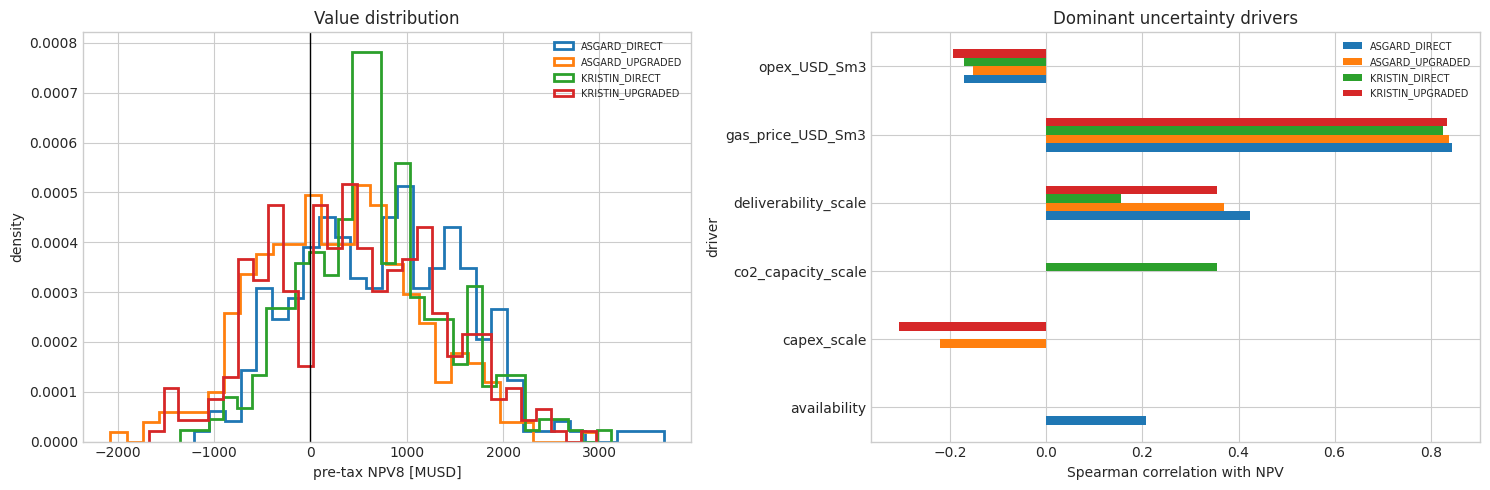

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for concept_name, subset in uncertainty.groupby("concept"):
    axes[0].hist(
        subset["NPV8_MUSD"], bins=30, histtype="step", lw=2,
        density=True, label=concept_name
    )
axes[0].axvline(0.0, color="black", lw=1)
axes[0].set_xlabel("pre-tax NPV8 [MUSD]")
axes[0].set_ylabel("density")
axes[0].set_title("Value distribution")
axes[0].legend(fontsize=7)

driver_plot = dominant_drivers.pivot(
    index="driver", columns="concept", values="spearman_rho"
).fillna(0.0)
driver_plot.plot(kind="barh", ax=axes[1])
axes[1].set_xlabel("Spearman correlation with NPV")
axes[1].set_title("Dominant uncertainty drivers")
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

The 1,200-draw emulator preserves each realization's reservoir scale, deliverability, host decline,
equipment capacities, availability, CAPEX, price, accepted volume, facility load, and NPV. The P10,
P50, and P90 representatives are actual rows nearest each value percentile—not independent marginal
inputs assembled into an internally impossible “Frankenstein” case. The emulator is checked against
the detailed NeqSim base result but does not replace full ERT-assisted model reruns.

## 12. Decision matrix and gated recommendation

In [44]:
decision = (
    uncertainty_summary.merge(economics, on="concept")
    .merge(capacity_summary[["concept", "held_back_BSm3"]], on="concept")
)
arrival_by_host = pipeline_results.query(
    "reservoir_case == 'LINNORM_BASE'"
).set_index("host")["arrival_bara"]
decision["hydraulic_margin_bar"] = decision["concept"].map(
    lambda name: arrival_by_host[HOST_CONCEPTS[name]["host"]]
    - route_scenarios[HOST_CONCEPTS[name]["host"]]["host_inlet_min_bara"]
)
decision["value_score"] = decision["P50_NPV8_MUSD"].rank(pct=True)
decision["holdback_score"] = (-decision["held_back_BSm3"]).rank(pct=True)
decision["robustness_score"] = (
    -decision["capacity_exceedance_probability"]
).rank(pct=True)
decision["hydraulic_score"] = decision["hydraulic_margin_bar"].rank(pct=True)
decision["simplicity_score"] = decision["concept"].map(
    lambda name: 1.0 if name.endswith("DIRECT") else 0.55
)
decision["weighted_score"] = (
    0.35 * decision["value_score"]
    + 0.25 * decision["robustness_score"]
    + 0.15 * decision["holdback_score"]
    + 0.15 * decision["hydraulic_score"]
    + 0.10 * decision["simplicity_score"]
)
decision = decision.sort_values("weighted_score", ascending=False)
display(decision[[
    "concept", "P10_NPV8_MUSD", "P50_NPV8_MUSD", "P90_NPV8_MUSD",
    "held_back_BSm3", "capacity_exceedance_probability", "Q90_max_CO2_util",
    "hydraulic_margin_bar", "CAPEX_MUSD", "weighted_score"
]])

,concept,P10_NPV8_MUSD,P50_NPV8_MUSD,P90_NPV8_MUSD,held_back_BSm3,capacity_exceedance_probability,Q90_max_CO2_util,hydraulic_margin_bar,CAPEX_MUSD,weighted_score
0,ASGARD_DIRECT,-362.7,758.1,"1,846",0,0.2367,0.9649,136.7,"1,687",0.8187
3,KRISTIN_UPGRADED,-651.2,447.3,"1,648",0,0.003333,0.7468,125.2,"2,053",0.6175
1,ASGARD_UPGRADED,-728.9,271.5,"1,384",0,0.003333,0.6596,136.7,"2,087",0.605
2,KRISTIN_DIRECT,-288.2,614.2,"1,686",1.727,0.64,0.9729,125.2,"1,603",0.5187


In [45]:
preferred = decision.iloc[0]
preferred_name = str(preferred["concept"])
preferred_host = HOST_CONCEPTS[preferred_name]["host"]
preferred_route = route_scenarios[preferred_host]
preferred_direct = preferred_name.endswith("DIRECT")
evidence_caveat = (
    "Because Åsgard equipment/nameplate margin is an analogue while Kristin's 18 MSm3/d "
    "gas capacity is published, an Åsgard front-runner is conditional on host-data "
    "confirmation; Kristin upgraded remains the evidence-backed fallback until both hosts "
    "return comparable operating-envelope data."
    if preferred_host == "ASGARD"
    else "Kristin has a published gas-nameplate anchor, but its current equipment-level "
    "ullage remains unverified; Åsgard must stay in the comparison until both hosts return "
    "comparable operating-envelope data."
)

recommendation_text = f'''
### Screening recommendation: advance {preferred_name.replace('_', ' ').title()} to concept select

**Produce Linnorm as a staged 2+1 well subsea gas development**, using the base Flow case as the
reference profile and the low/high cases as the deliverability envelope. Route an approximately
{preferred_route['distance_km']:.1f} km straight-line-equivalent, {preferred_route['diameter_m']/0.0254:.0f}-inch
wet-gas line to **{preferred_host.title()}**, with inlet heating/MEG and corrosion-resistant material
decisions held behind verified water, CO2, and H2S data.

The preferred screen has median pre-tax NPV8 of **{preferred['P50_NPV8_MUSD']:.0f} MUSD**, P10/P90
of **{preferred['P10_NPV8_MUSD']:.0f}/{preferred['P90_NPV8_MUSD']:.0f} MUSD**, and an unconstrained
capacity-exceedance probability of **{100*preferred['capacity_exceedance_probability']:.0f}%**.
Its Q90 maximum CO2-train utilization is **{100*preferred['Q90_max_CO2_util']:.0f}%**. These are
scenario results, not booked capacity.

{evidence_caveat}

**Operating strategy:** protect base-host production; initially open two Linnorm wells, use the third
as deliverability/decline support, cap the satellite against the area-qualified NeqSim bottleneck,
and defer rather than destroy gas where later host decline creates ullage. Pre-invest tie-in spools,
controls, and plot space for modular CO2 removal/compression. If verified CO2 capacity or Q90 load
fails the 95% utilization gate, select the upgraded variant before first gas.
'''
display(Markdown(recommendation_text))


### Screening recommendation: advance Asgard Direct to concept select

**Produce Linnorm as a staged 2+1 well subsea gas development**, using the base Flow case as the
reference profile and the low/high cases as the deliverability envelope. Route an approximately
73.8 km straight-line-equivalent, 20-inch
wet-gas line to **Asgard**, with inlet heating/MEG and corrosion-resistant material
decisions held behind verified water, CO2, and H2S data.

The preferred screen has median pre-tax NPV8 of **758 MUSD**, P10/P90
of **-363/1846 MUSD**, and an unconstrained
capacity-exceedance probability of **24%**.
Its Q90 maximum CO2-train utilization is **96%**. These are
scenario results, not booked capacity.

Because Åsgard equipment/nameplate margin is an analogue while Kristin's 18 MSm3/d gas capacity is published, an Åsgard front-runner is conditional on host-data confirmation; Kristin upgraded remains the evidence-backed fallback until both hosts return comparable operating-envelope data.

**Operating strategy:** protect base-host production; initially open two Linnorm wells, use the third
as deliverability/decline support, cap the satellite against the area-qualified NeqSim bottleneck,
and defer rather than destroy gas where later host decline creates ullage. Pre-invest tie-in spools,
controls, and plot space for modular CO2 removal/compression. If verified CO2 capacity or Q90 load
fails the 95% utilization gate, select the upgraded variant before first gas.


### Do not pass concept select until these data gates close

1. Obtain pressure-volume-temperature samples by compartment and tune an EOS to CCE/CVD/separator data.
2. Reconcile SODIR recoverable volumes with seismic depth conversion, contacts, net pay, SCAL, and
   compartment connectivity; history-match appraisal pressure if available.
3. Obtain Kristin and Åsgard equipment-by-equipment operating envelopes, shutdown constraints,
   maintenance plans, export nominations, fuel/flare emissions, and tariff/access terms.
4. Survey both routes and run multiphase transients for ramp-up, turndown, shutdown, cooldown,
   depressurization, restart, slugging, MEG regeneration, and hydrate remediation.
5. Verify produced-water chemistry, 7–8 mol% CO2 distribution, 15–30 ppm H2S, corrosion/erosion,
   material selection, and sour-service qualification.
6. Re-run the coupled cases in ERT with geological ensembles and replace the economic assumptions
   with schedule, tax, emissions, abandonment, tariffs, and decision-tree value.

## 13. Export the auditable decision package

In [46]:
export_tables = {
    "sources.csv": sources,
    "evidence.csv": evidence,
    "case_assumptions.csv": case_table.reset_index(names="case"),
    "pvt.csv": pvt_all,
    "reservoir_forecasts.csv": forecasts,
    "restart_summary.csv": restart_summary,
    "pipeline_screen.csv": pipeline_results,
    "hydrate_screen.csv": hydrate_screen,
    "corrosion_screen.csv": corrosion_screen,
    "capacity_periods.csv": capacity_periods,
    "capacity_summary.csv": capacity_summary,
    "policy_sensitivity.csv": policy_sensitivity,
    "maximum_load_process.csv": max_load_results,
    "economics.csv": economics,
    "uncertainty.csv": uncertainty,
    "uncertainty_summary.csv": uncertainty_summary,
    "representative_cases.csv": representative_cases,
    "uncertainty_drivers.csv": uncertainty_drivers,
    "decision_matrix.csv": decision,
}
for filename, table in export_tables.items():
    table.to_csv(EXPORT_DIR / filename, index=False)

deck_export = EXPORT_DIR / "opm_flow_decks"
deck_export.mkdir(exist_ok=True)
for case_name, path in deck_paths.items():
    shutil.copy2(path, deck_export / path.name)

diagnostics = {
    "session_utc": SESSION_UTC,
    "neqsim_master_sha": MASTER_SHA,
    "neqsim_code_source": str(code_source),
    "opm_flow_version": flow_version,
    "preferred_concept": preferred_name,
    "process_utilization_json": {
        name: str(bundle["model"].getUtilizationSnapshotJson())
        for name, bundle in host_processes.items()
    },
    "process_validation": {
        name: str(bundle["model"].validateAll())
        for name, bundle in host_processes.items()
    },
    "process_mass_balance": {
        name: str(bundle["model"].checkMassBalance())
        for name, bundle in host_processes.items()
    },
}
(EXPORT_DIR / "run_diagnostics.json").write_text(
    json.dumps(diagnostics, indent=2, ensure_ascii=False)
)

manifest_rows = []
for path in sorted(EXPORT_DIR.rglob("*")):
    if path.is_file() and path.name != "sha256_manifest.csv":
        manifest_rows.append({
            "path": str(path.relative_to(EXPORT_DIR)),
            "bytes": path.stat().st_size,
            "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
        })
sha_manifest = pd.DataFrame(manifest_rows)
sha_manifest.to_csv(EXPORT_DIR / "sha256_manifest.csv", index=False)

archive_path = shutil.make_archive(
    str(RUN_ROOT / "linnorm_tie_in_decision_package"), "zip", EXPORT_DIR
)
display(sha_manifest.head(10))
print("Decision package:", archive_path)

Decision package: /workspace/scratch/04ade5196498/linnorm_tie_in_run/ab314d6a0f/linnorm_tie_in_decision_package.zip


,path,bytes,sha256
0,capacity_periods.csv,13726,ff0d60d1c45b5bd3c4adb9a1024acdd34bba11bb2f7033ecdf72e141fe4d75cf
1,capacity_summary.csv,474,4ae7ff94f5091f209bf16b0253b9742beabb5acb2d7b5106a8f34b05bd0c23db
2,case_assumptions.csv,390,b8fe457b200971e3321dae4c6aab5d73e765cc40af20ae3d9d0e28f8a5b25722
3,corrosion_screen.csv,285,23fa669957eab966b8a6f985697c7c1bca10d9985bf11a174bd01d62bc342522
4,decision_matrix.csv,1723,4d97d1fc939483eab4598909c0458142e2c7bf32024eb59bc981d4a975bc6157
5,economics.csv,586,4561638cc9b23b74110f0a74c264f36858ef368adc4a626e2c549558dbfb0c29
6,evidence.csv,654,d68b11ed798c44145ceff38b6322fe53740a3fab64fad190f0b4bfcd8b0761e5
7,hydrate_screen.csv,171,30431a28ea5907aa1a3df8fb046f4e2a36040f78b83becb0cf2f667b86f4068b
8,maximum_load_process.csv,255,a047ac6e2f045c53e6c158ad008aa4a508490760149a0a3c8812754dc2f30285
9,opm_flow_decks/ASGARD_HOST.DATA,18207,ae8fb9bc7ac2b556b6d8541843f0dc6cefcd4929aee3a41262b1efdcc2f545c5


## 14. Machine-checkable acceptance gates

In [47]:
acceptance_gates = {
    "exact NeqSim master SHA recorded": bool(re.fullmatch(r"[0-9a-f]{40}", MASTER_SHA)),
    "master multi-area API contract passed": bool((api_contract_df["missing"] == "none").all()),
    "SODIR live resource is 31.411 BSm3": abs(
        float(resources["dscRecoverableGas"]) - 31.411
    ) < 1.0e-6,
    "well narrative checks passed": bool(page_checks["found_on_live_page"].all()),
    "five Flow cases completed": len(flow_runs) == 5 and all(
        run["returncode"] == 0 for run in flow_runs.values()
    ),
    "Flow restart states physical": bool(
        (restart_summary["mean_pressure_bara"] > 0.0).all()
        and restart_summary["mean_sgas"].between(0.0, 1.0).all()
        and restart_summary["mean_swat"].between(0.0, 1.0).all()
    ),
    "Linnorm forecasts stay within scenario resources": all(
        float(forecasts.loc[
            forecasts["case"] == case_name, "gas_cum_bsm3"
        ].max()) <= CASES[case_name]["resource_bsm3"] * 1.01
        for case_name in ["LINNORM_LOW", "LINNORM_BASE", "LINNORM_HIGH"]
    ),
    "pipeline arrivals above host minimum": bool(all(
        row.arrival_bara > route_scenarios[row.host]["host_inlet_min_bara"]
        for row in pipeline_results.itertuples()
    )),
    "planner restored every host feed": len(capacity_results) == 4,
    "maximum-load amine result finite": bool(
        np.isfinite(max_load_results["treated_CO2_molpct"]).all()
    ),
    "uncertainty outputs finite": bool(
        np.isfinite(uncertainty[["NPV8_MUSD", "accepted_BSm3"]]).all().all()
    ),
    "decision package hashed": len(sha_manifest) >= 18,
}
acceptance = pd.DataFrame([
    {"gate": gate, "passed": passed} for gate, passed in acceptance_gates.items()
])
display(acceptance)
assert acceptance["passed"].all(), acceptance.loc[~acceptance["passed"]]
print("ALL ACCEPTANCE GATES PASSED")

ALL ACCEPTANCE GATES PASSED


,gate,passed
0,exact NeqSim master SHA recorded,True
1,master multi-area API contract passed,True
2,SODIR live resource is 31.411 BSm3,True
3,well narrative checks passed,True
4,five Flow cases completed,True
5,Flow restart states physical,True
6,Linnorm forecasts stay within scenario resources,True
7,pipeline arrivals above host minimum,True
8,planner restored every host feed,True
9,maximum-load amine result finite,True


## References and reproducibility notes

- [SODIR facts](https://www.sodir.no/en/facts/) and
  [open data](https://www.sodir.no/en/facts/data-and-analyses/open-data/)
- [SODIR FactMaps ArcGIS home](https://sodir.maps.arcgis.com/home/index.html) and
  [FactMaps WGS84 service](https://factmaps.sodir.no/api/rest/services/Factmaps/FactMapsWGS84/FeatureServer)
- [SODIR 6406/9-1 well page](https://factpages.sodir.no/wellbore/pageview/exploration/all/4927)
- [Equinor: Linnorm host alternatives](https://www.equinor.com/news/20231214-increasing-ownership-linnorm-discovery)
- [Equinor: Kristin](https://www.equinor.com/energy/kristin) and
  [Åsgard](https://www.equinor.com/energy/asgard)
- [Gassco transport map](https://gassco.eu/en/transport-map/)
- [OPM public SPE5 E300 PVT basis](https://github.com/OPM/opm-publications/blob/1aef1411ac4ad953cece5684a380b46fddfb9357/dynamic_blackoil/SPE5e300PVT)
- [OPM Flow documentation](https://opm-project.org/?page_id=19)
- [NeqSim master repository](https://github.com/equinor/neqsim) and
  [host tie-in capacity guide](https://github.com/equinor/neqsim/blob/master/docs/fielddevelopment/HOST_TIE_IN_CAPACITY.md)

To reproduce a future-master run exactly, set `NEQSIM_MASTER_REF` to the printed 40-character SHA.
The default deliberately follows `master`, builds Java source in Colab, fails if the used API changes,
records Flow version, exports all tables/decks/diagnostics, and hashes the decision package.